In [1]:
from pathlib import Path
import pandas as pd
from functools import reduce
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler

# Crear tablas comparativas

In [2]:
reports_dir = Path("../reports")

files = sorted(reports_dir.glob("*/*_xai_metrics_report_*.csv"))

metric_dfs = []

for metric_dir in sorted({file.parent for file in files}):
    metric_name = metric_dir.name
    metric_files = sorted(metric_dir.glob("*_xai_metrics_report_*.csv"))

    long_parts = []

    for file in metric_files:
        df = pd.read_csv(file)

        if 'observation' not in df.columns:
            continue

        df['dataset_name'] = df['dataset_name'].astype(str)
        df['model_name'] = df['model_name'].astype(str)
        df['observation'] = df['observation'].astype(str)

        id_cols = ['dataset_name', 'model_name', 'observation', 'metric_params']
        xai_cols = [c for c in df.columns if c not in id_cols]

        long_parts.append(
            df.melt(
                id_vars=['dataset_name', 'model_name', 'observation'],
                value_vars=xai_cols,
                var_name="xai_method",
                value_name=metric_name
            )
        )

    if long_parts:
        metric_df = pd.concat(long_parts, ignore_index=True)
        metric_df['xai_method'] = metric_df['xai_method'].astype(str)
        metric_dfs.append(metric_df)

if not metric_dfs:
    raise ValueError("No se han encontrado informes por observación.")

analysis_df = reduce(
    lambda left, right: pd.merge(
        left,
        right,
        on=["dataset_name", "model_name", "observation", "xai_method"],
        how="outer",
    ),
    metric_dfs,
)

Path('results').mkdir(exist_ok=True)
analysis_df.to_csv("results/metric_analysis_matrix.csv", index=False)

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3.0,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2.0,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3.0,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3.0,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2.0,NaN,NaN,NaN,0.711035,0.000000


In [3]:
from pathlib import Path
import pandas as pd

reports_dir = Path("../reports")

files = sorted(reports_dir.glob("xai_metrics_report_*.csv"))

parts = []

for file in files:
    df = pd.read_csv(file)

    id_cols = ["dataset_name", "model_name", "metric", "metric_params"]
    xai_cols = [c for c in df.columns if c not in id_cols]

    long_df = df.melt(
        id_vars=["dataset_name", "model_name", "metric"],
        value_vars=xai_cols,
        var_name="xai_method",
        value_name="value"
    )

    parts.append(long_df)

agg_long = pd.concat(parts, ignore_index=True)

analysis_agg_df = agg_long.pivot_table(
    index=["dataset_name", "model_name", "xai_method"],
    columns="metric",
    values="value",
    aggfunc="mean"
).reset_index()

analysis_agg_df.columns.name = None

id_cols = ["dataset_name", "model_name", "xai_method"]

metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors="coerce")


Path('results').mkdir(exist_ok=True)
analysis_agg_df.to_csv("results/metric_analysis_agg_matrix.csv", index=False)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


# Análisis de métricas por observación

In [4]:
matrix_path = Path("results/metric_analysis_matrix.csv")
analysis_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'observation', 'xai_method']
global_metrics = ['SensitivityN']

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,True,0.357843,False,3.0,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,True,0.232843,False,2.0,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,True,-0.181373,False,3.0,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,True,0.338235,False,3.0,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,True,0.215686,False,2.0,NaN,NaN,NaN,0.711035,0.000000


## Análisis descriptivo de las métricas

In [5]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

summary = analysis_df[metric_cols].describe().T

summary['missing'] = analysis_df[metric_cols].isna().sum()
summary['missing_pct'] = analysis_df[metric_cols].isna().mean() * 100
summary['std'] = analysis_df[metric_cols].std()
summary['range'] = summary['max'] - summary['min']

summary['scope'] = 'individual'
summary.loc[summary.index.isin(global_metrics), 'scope'] = 'global'

summary['interpretation_note'] = ""
summary.loc[
    summary.index.isin(global_metrics),
    'interpretation_note'
] = "Métrica global; no se calcula por observación individual."


summary = summary[
    ['scope', 'mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'interpretation_note']
].sort_values(['scope', 'std'], ascending=False)

summary

,scope,mean,std,min,max,range,missing,missing_pct,interpretation_note
RelativeOutputStability,individual,9.037405e+08,2.329522e+10,9.010076e-01,7.436560e+11,7.436560e+11,1411,57.922824,
MaxSensitivity,individual,3.308260e+02,5.010763e+03,6.196479e-02,1.252843e+05,1.252842e+05,280,11.494253,
RelativeInputStability,individual,4.570600e+02,4.236374e+03,1.346755e-06,1.083559e+05,1.083559e+05,1413,58.004926,
AvgSensitivity,individual,2.391012e+02,3.634266e+03,3.275383e-02,9.097839e+04,9.097836e+04,350,14.367816,
LocalLipschitzEstimate,individual,6.037597e+00,4.006262e+00,1.680686e-01,3.137428e+01,3.120621e+01,140,5.747126,
NonSensitivity,individual,3.180314e+00,2.556495e+00,0.000000e+00,1.200000e+01,1.200000e+01,140,5.747126,
Complexity,individual,1.614151e+00,5.643636e-01,-1.000089e-12,2.754321e+00,2.754321e+00,140,5.747126,
FaithfulnessEstimate,individual,-2.979342e-02,5.195057e-01,-9.999986e-01,9.999970e-01,1.999996e+00,140,5.747126,
Faithfulness,individual,-9.759366e-02,5.083429e-01,-9.999955e-01,9.937259e-01,1.993721e+00,140,5.747126,
Sufficiency,individual,5.074085e-01,4.274774e-01,0.000000e+00,1.000000e+00,1.000000e+00,140,5.747126,


In [6]:
sns.set_theme(style='whitegrid', context='notebook')

summary_plot = summary.copy()

if 'scope' in summary_plot.columns:
    summary_plot = summary_plot[summary_plot['scope'] == 'individual']
else:
    summary_plot = summary_plot.drop(index=global_metrics, errors='ignore')

summary_plot = summary_plot.sort_values('std', ascending=False)

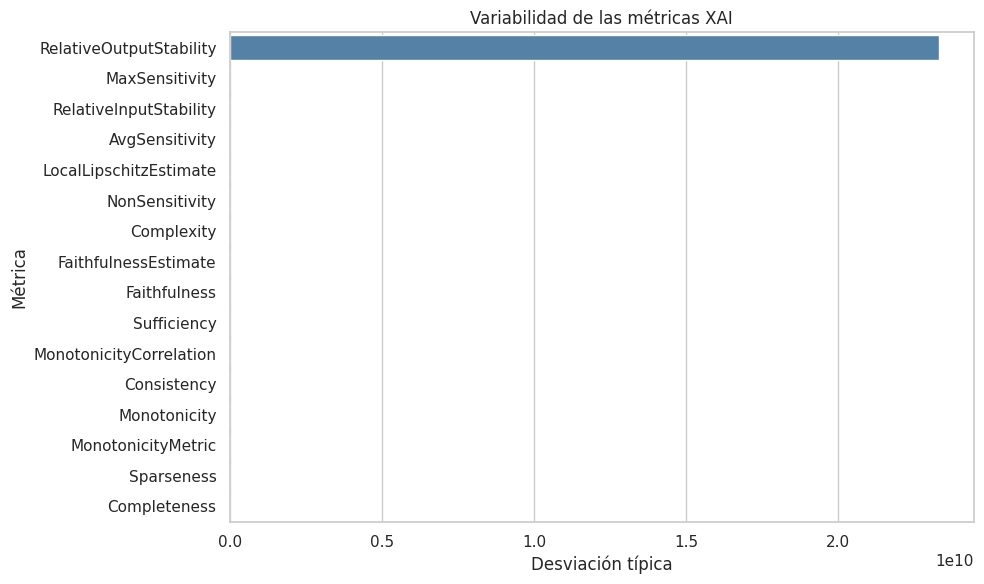

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

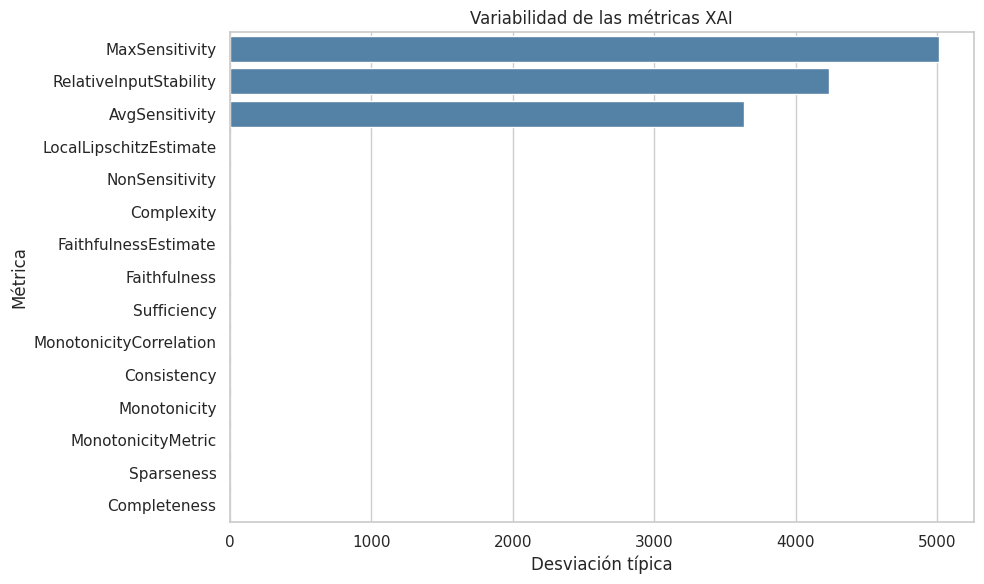

In [8]:
summary_plot_aux = summary_plot.drop(index=['RelativeOutputStability'])
plt.figure(figsize=(10, 6))

sns.barplot(
    data=summary_plot_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)

plt.title("Variabilidad de las métricas XAI")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

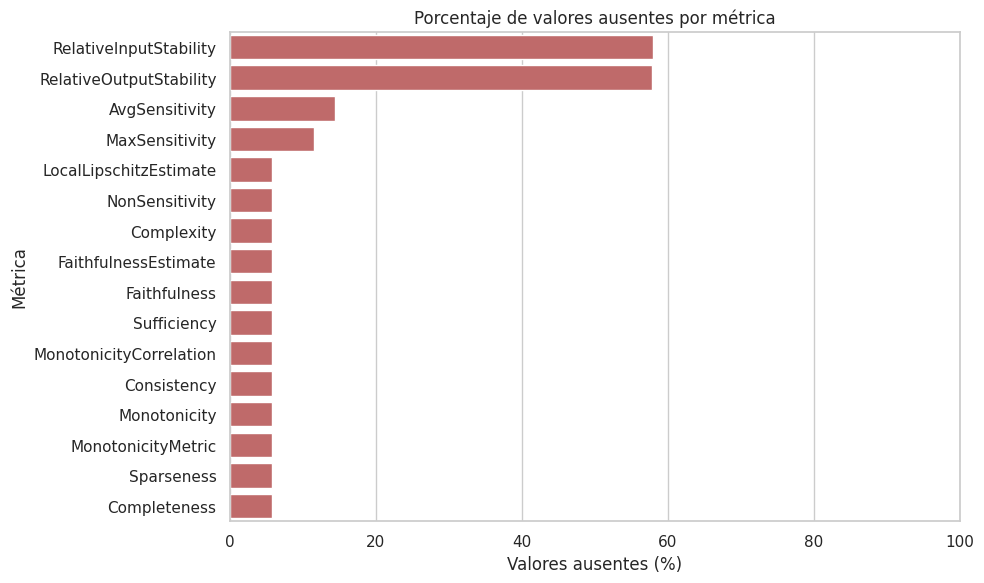

In [9]:
missing_plot = summary_plot.sort_values("missing_pct", ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=missing_plot.reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)

plt.title("Porcentaje de valores ausentes por métrica")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

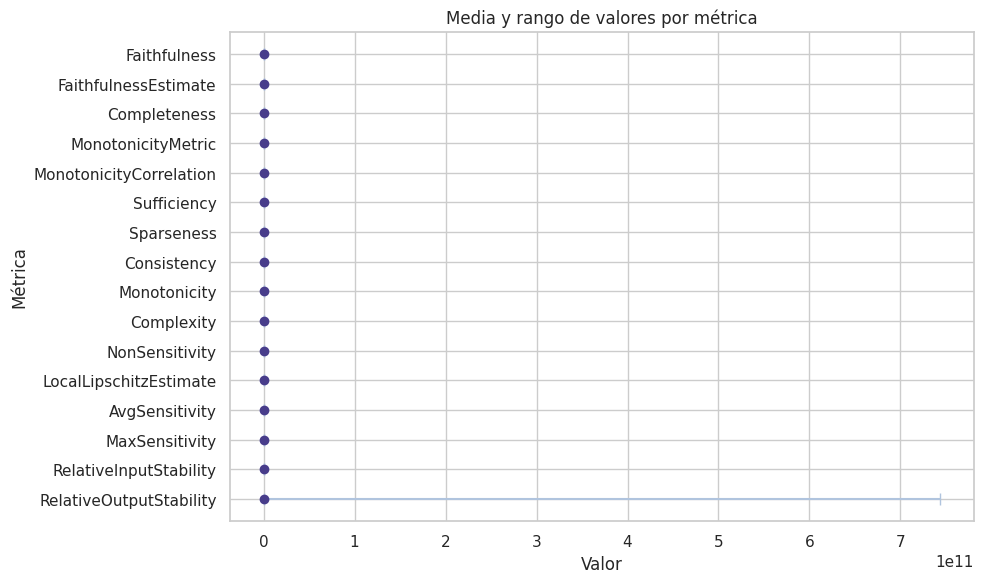

In [10]:
range_plot = summary_plot.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

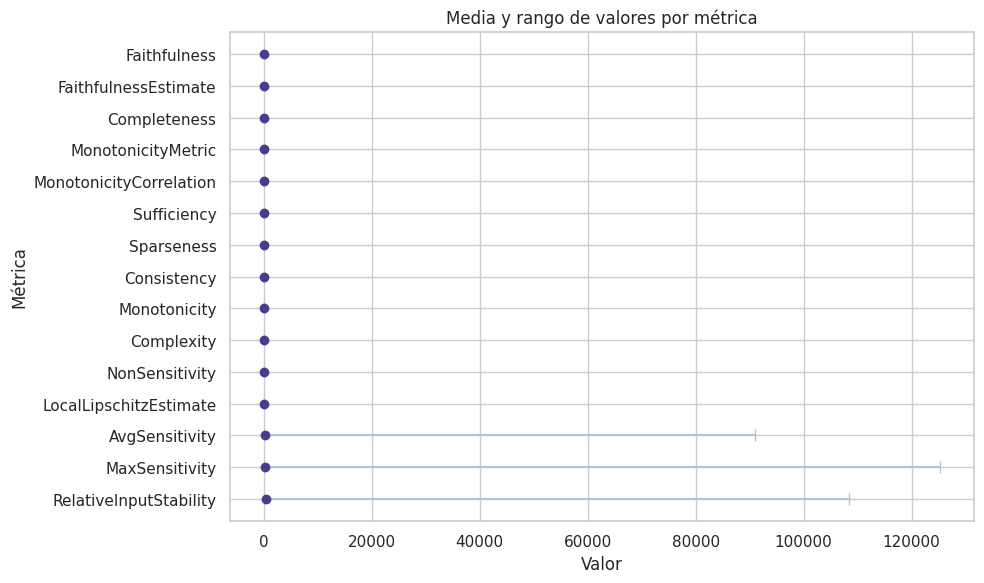

In [11]:
range_plot = summary_plot_aux.sort_values("mean", ascending=False).reset_index()

plt.figure(figsize=(10, 6))

plt.errorbar(
    x=range_plot["mean"],
    y=range_plot["index"],
    xerr=[
        range_plot["mean"] - range_plot["min"],
        range_plot["max"] - range_plot["mean"]
    ],
    fmt="o",
    color="darkslateblue",
    ecolor="lightsteelblue",
    capsize=4
)

plt.title("Media y rango de valores por métrica")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

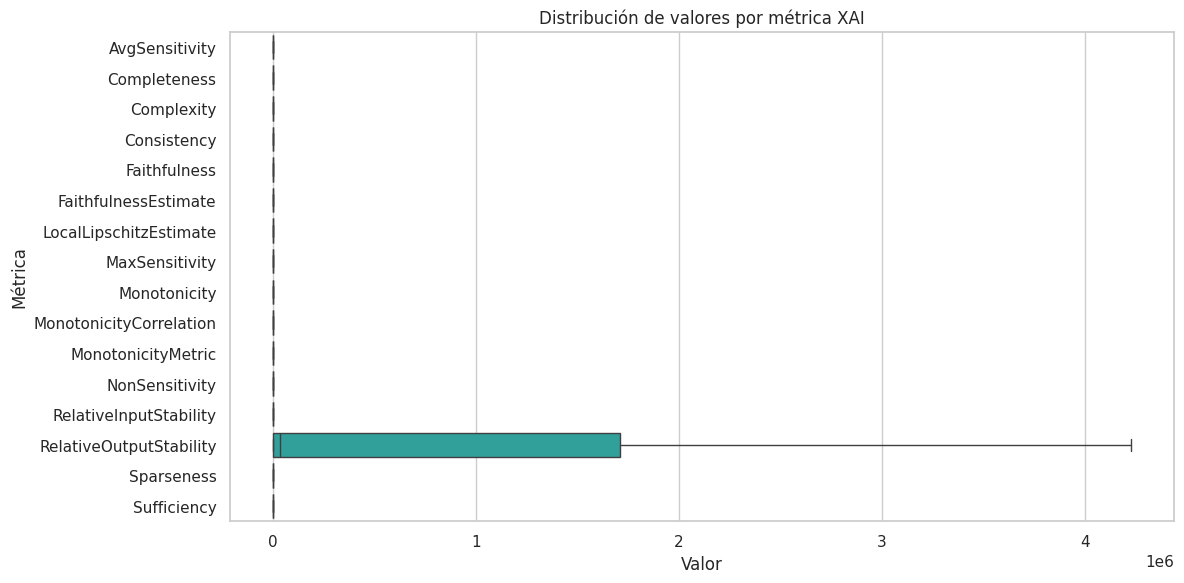

In [12]:
metric_cols_individual = [
    c for c in metric_cols
    if c not in global_metrics
]

plot_df = analysis_df[metric_cols_individual].copy()

for col in metric_cols_individual:
    plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

plot_long = plot_df.melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)

plt.title("Distribución de valores por métrica XAI")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

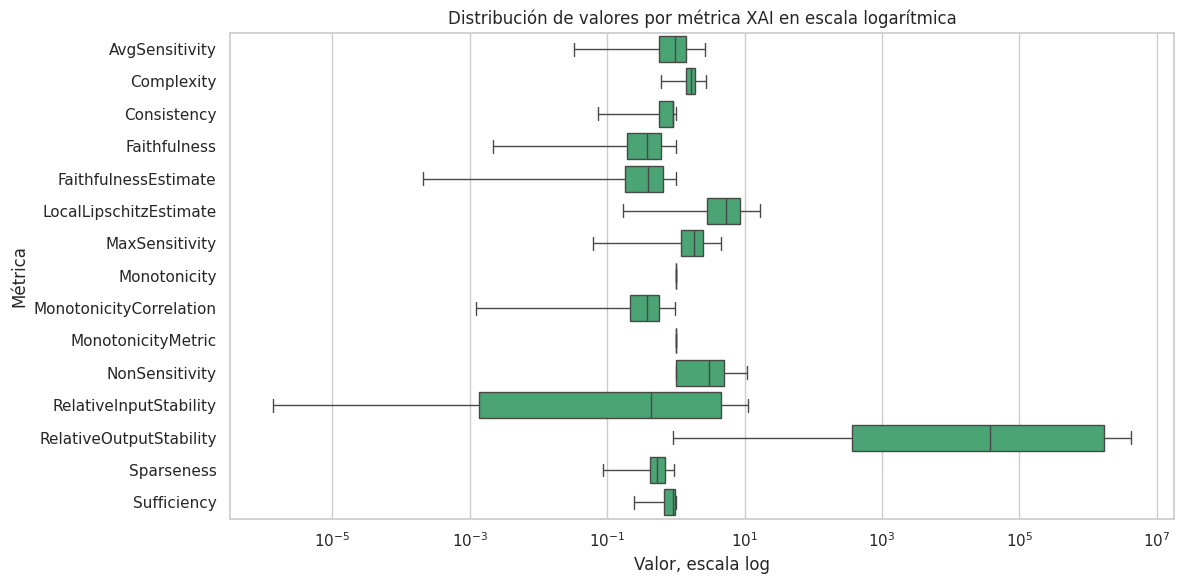

In [13]:
plot_long_positive = plot_long[plot_long["value"] > 0].copy()

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=plot_long_positive,
    x="value",
    y="metric",
    color="mediumseagreen",
    showfliers=False
)

plt.xscale("log")
plt.title("Distribución de valores por métrica XAI en escala logarítmica")
plt.xlabel("Valor, escala log")
plt.ylabel("Métrica")
plt.tight_layout()
plt.show()

## Correlación entre métricas

In [14]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

X = analysis_df[metric_cols].dropna(axis=0, how='any')

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=metric_cols,
    index=X.index
)

corr = X_scaled.corr(method='spearman')

corr

,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,Sparseness,Sufficiency
AvgSensitivity,1.000000,NaN,-0.049732,0.374330,-0.232845,0.003273,0.132149,0.899070,0.012009,0.044866,-0.142449,0.439333,-0.018732,0.439966,0.259664,0.193782
Completeness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complexity,-0.049732,NaN,1.000000,-0.604192,0.160098,0.106387,0.014631,-0.159041,0.023334,-0.374129,0.049823,-0.289231,0.003836,-0.393093,-0.843349,0.138433
Consistency,0.374330,NaN,-0.604192,1.000000,-0.358758,-0.074407,-0.099681,0.461015,-0.127636,0.395773,-0.208033,0.382181,-0.118197,0.498518,0.655573,0.138348
Faithfulness,-0.232845,NaN,0.160098,-0.358758,1.000000,0.016825,-0.064318,-0.234573,0.128923,-0.148682,0.200694,-0.207721,0.107355,-0.179681,-0.220246,-0.219264
FaithfulnessEstimate,0.003273,NaN,0.106387,-0.074407,0.016825,1.000000,-0.033997,-0.010071,0.044492,-0.049698,0.037507,-0.117803,0.053499,-0.011727,-0.070368,0.155656
LocalLipschitzEstimate,0.132149,NaN,0.014631,-0.099681,-0.064318,-0.033997,1.000000,-0.036304,-0.027348,-0.132221,0.071728,0.033567,0.223290,0.114846,-0.128423,-0.159050
MaxSensitivity,0.899070,NaN,-0.159041,0.461015,-0.234573,-0.010071,-0.036304,1.000000,0.099468,0.115116,-0.126849,0.426083,-0.080360,0.373197,0.341741,0.180929
Monotonicity,0.012009,NaN,0.023334,-0.127636,0.128923,0.044492,-0.027348,0.099468,1.000000,-0.012581,0.059914,0.164596,-0.208612,-0.322914,0.002949,0.090400
MonotonicityCorrelation,0.044866,NaN,-0.374129,0.395773,-0.148682,-0.049698,-0.132221,0.115116,-0.012581,1.000000,-0.072787,0.166607,-0.209227,0.104084,0.399828,0.124027


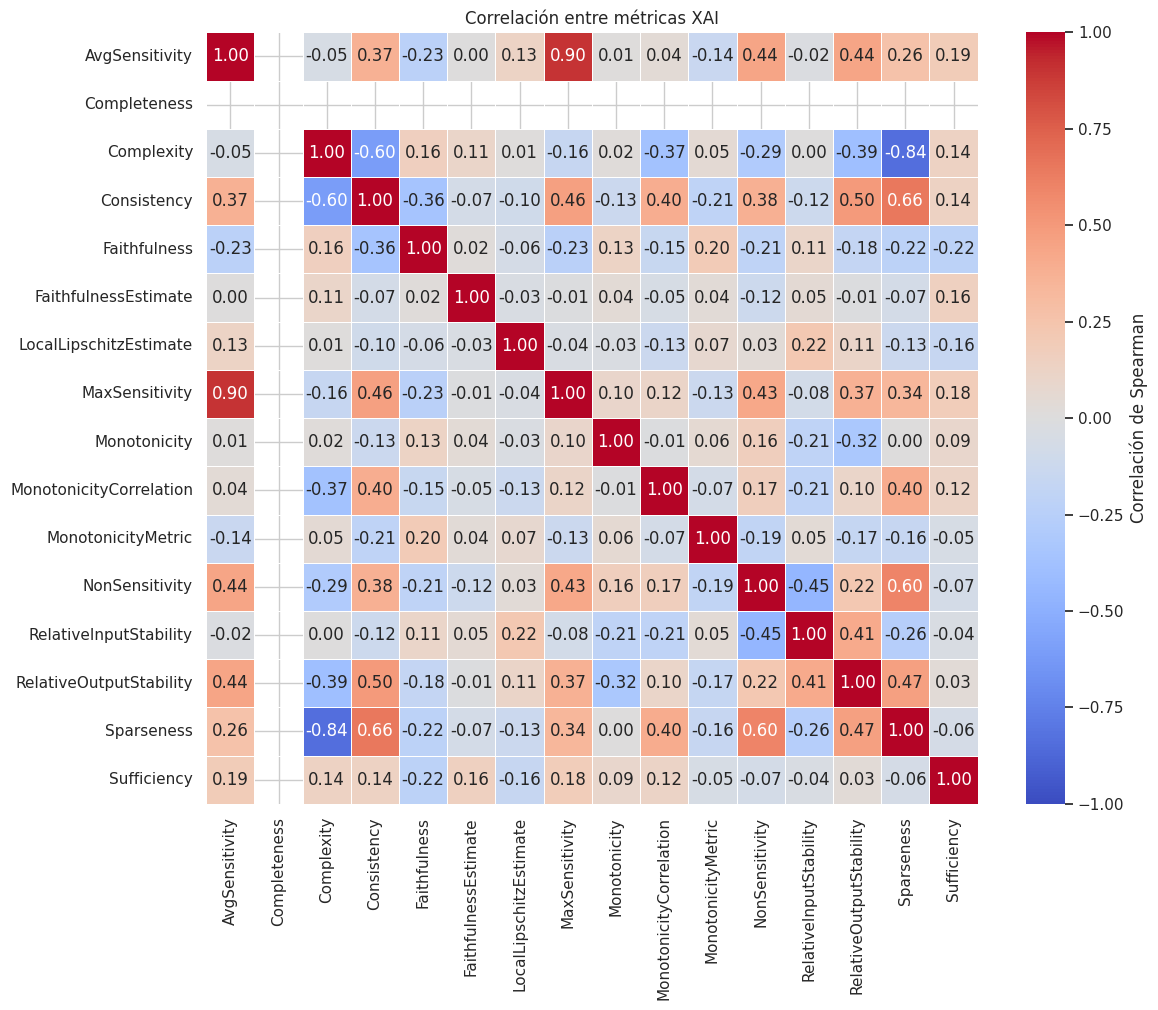

In [15]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas XAI")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(output_dir / "correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
corr_pairs = (
    corr.where(~pd.DataFrame(
        [[i >= j for j in range(len(corr.columns))] for i in range(len(corr.index))],
        index=corr.index,
        columns=corr.columns
    ))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

strong_corr = corr_pairs[
    corr_pairs["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

strong_corr

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.899070,0.899070
25,Complexity,Sparseness,-0.843349,0.843349
37,Consistency,Sparseness,0.655573,0.655573
14,Complexity,Consistency,-0.604192,0.604192
97,NonSensitivity,Sparseness,0.600293,0.600293


In [17]:
mean_abs_corr = corr.abs().copy()

for col in mean_abs_corr.columns:
    mean_abs_corr.loc[col, col] = pd.NA

independence_summary = (
    mean_abs_corr.mean(axis=1)
    .sort_values()
    .reset_index()
)

independence_summary.columns = ["metric", "mean_abs_correlation"]

independence_summary

,metric,mean_abs_correlation
0,FaithfulnessEstimate,0.056122
1,LocalLipschitzEstimate,0.090825
2,Monotonicity,0.094655
3,MonotonicityMetric,0.112533
4,Sufficiency,0.118344
5,RelativeInputStability,0.159490
6,MonotonicityCorrelation,0.167830
7,Faithfulness,0.177142
8,Complexity,0.229236
9,AvgSensitivity,0.231586


## Clustering jerárquico de métricas

In [18]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

In [19]:
Path('results').mkdir(exist_ok=True)

corr_cluster = corr.copy()

corr_cluster = corr_cluster.dropna(axis=0, how='all').dropna(axis=1, how='all')

valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics]

corr_cluster = corr_cluster.fillna(0)

distance = 1 - corr_cluster.abs()
np.fill_diagonal(distance.values, 0)

linkage_matrix = linkage(
    squareform(distance),
    method='average'
)

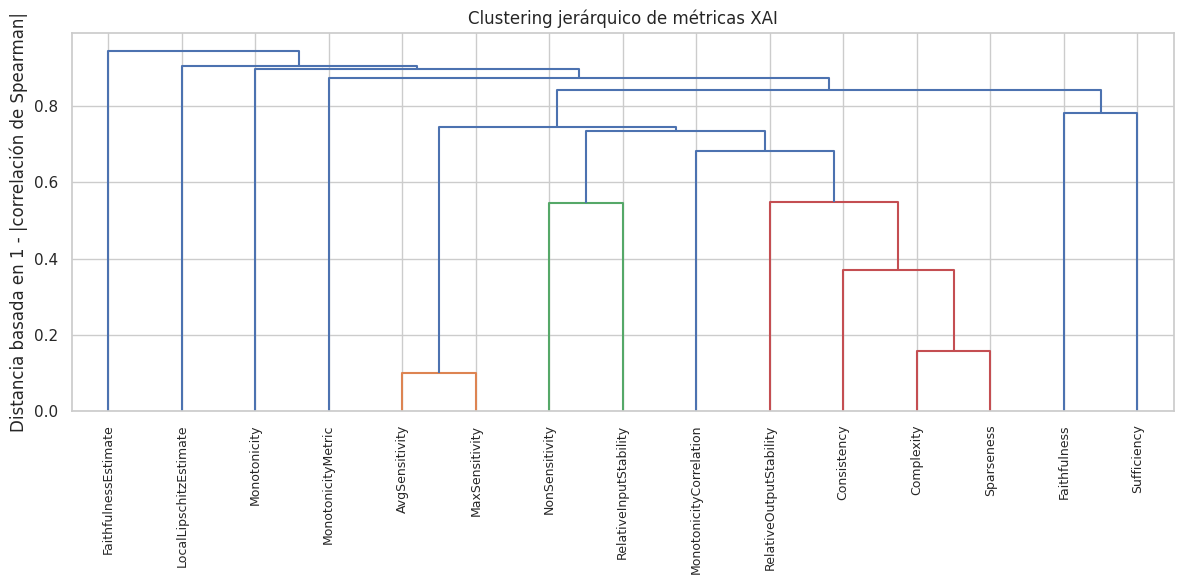

In [20]:
output_dir = Path("results/conclusions_obs_results")
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix,
    labels=corr_cluster.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas XAI")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(output_dir / "dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

In [21]:
from scipy.stats import kruskal

In [22]:
sns.set_theme(style='whitegrid', context='notebook')

results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(exist_ok=True)

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')

factors = ["dataset_name", "model_name", "xai_method"]

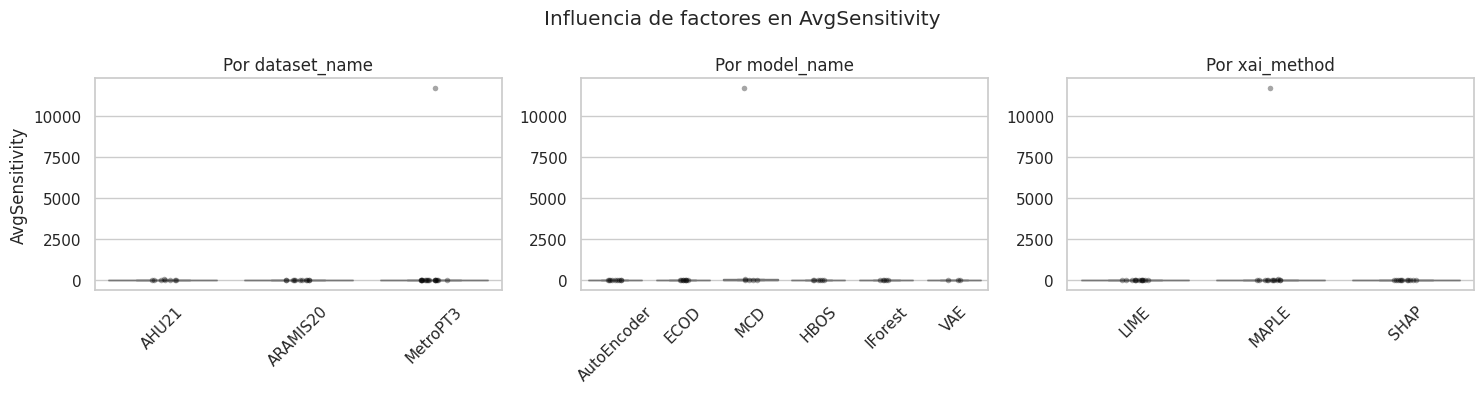

Saltando Completeness: no tiene variabilidad suficiente.


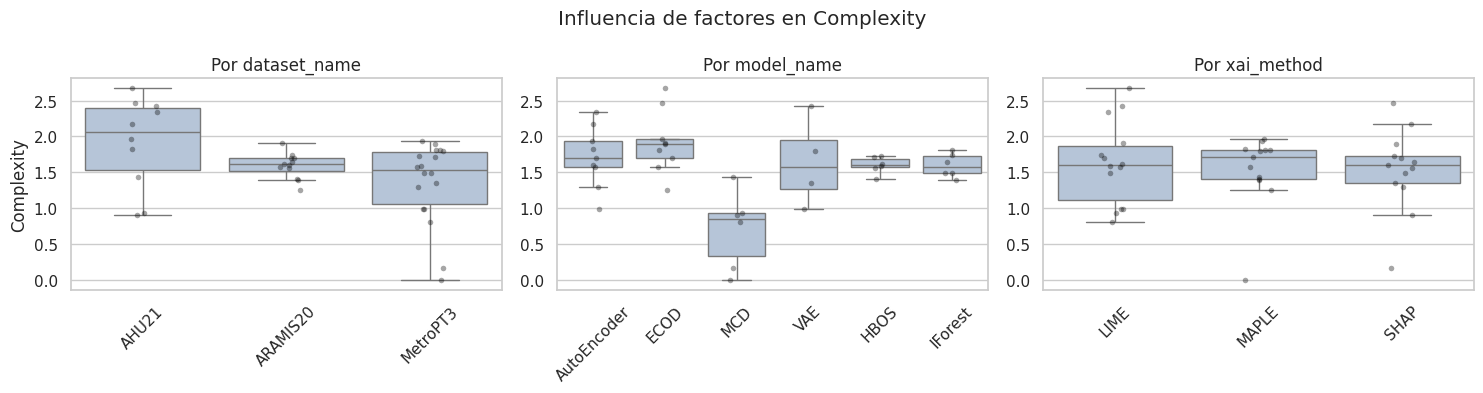

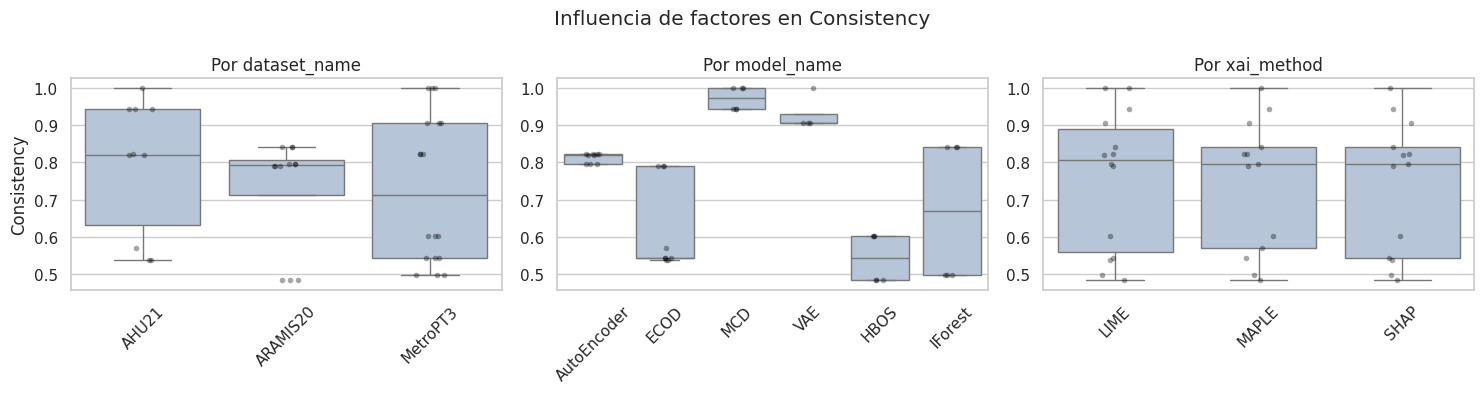

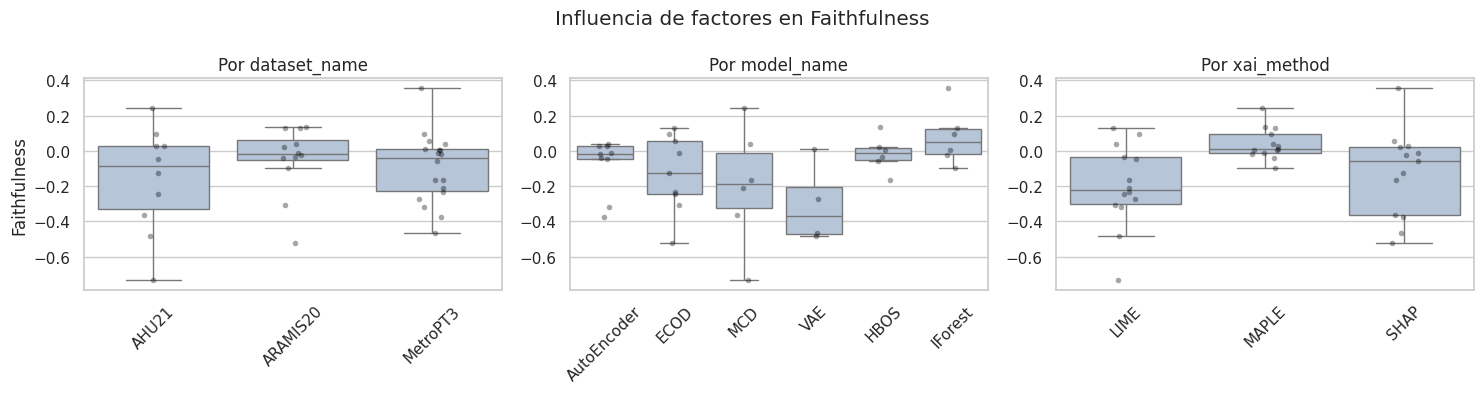

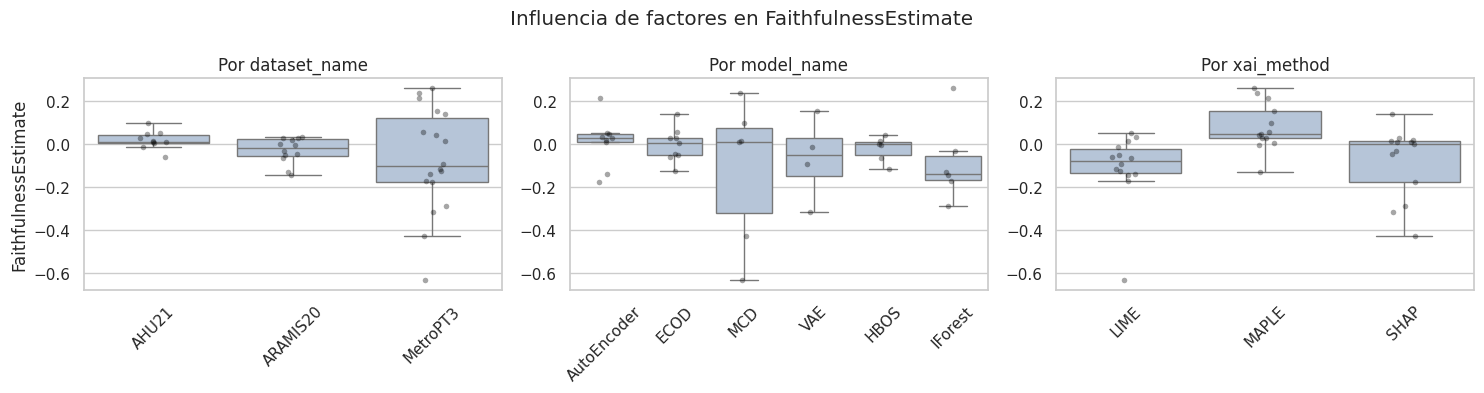

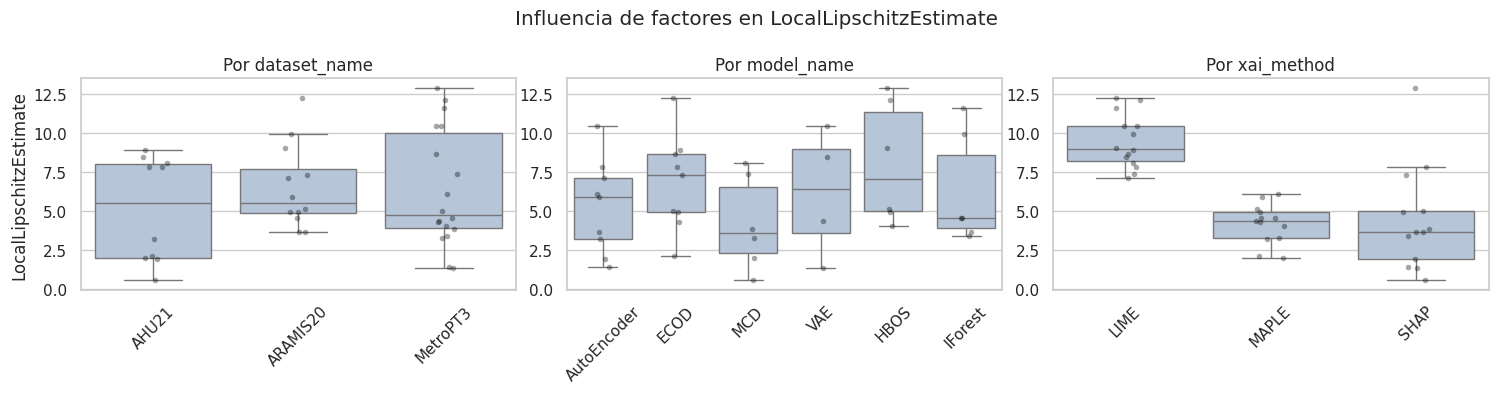

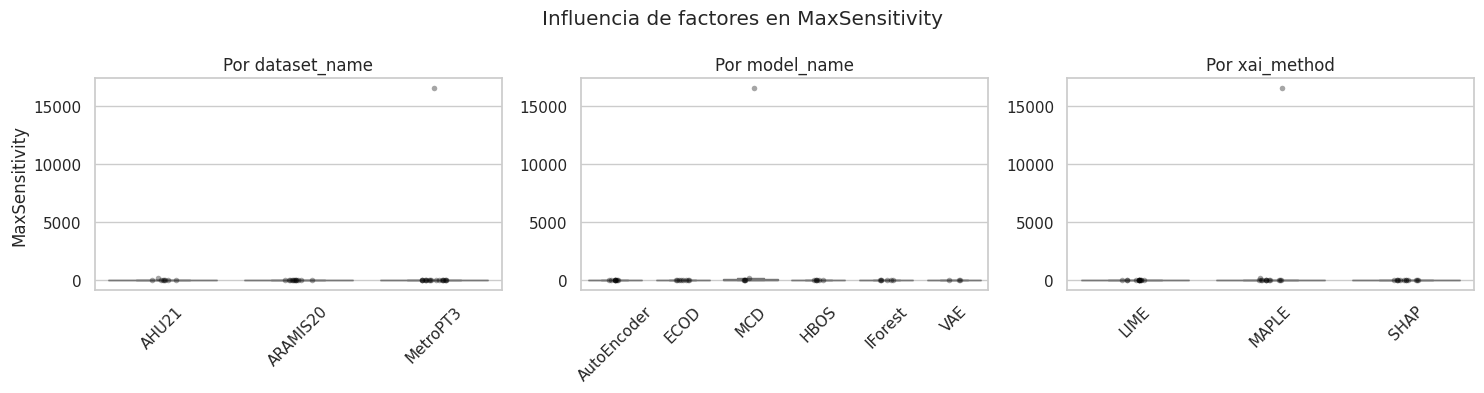

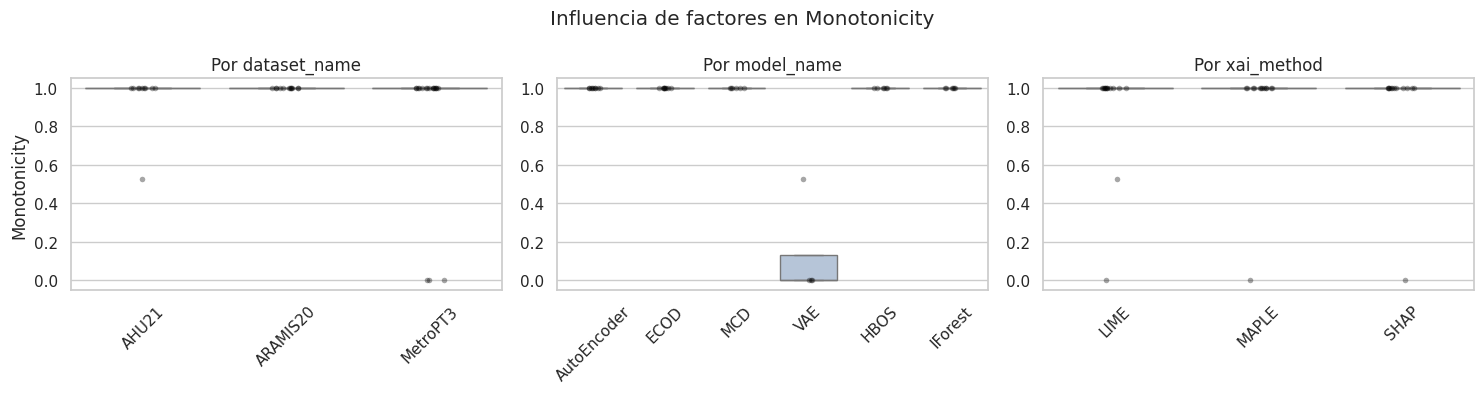

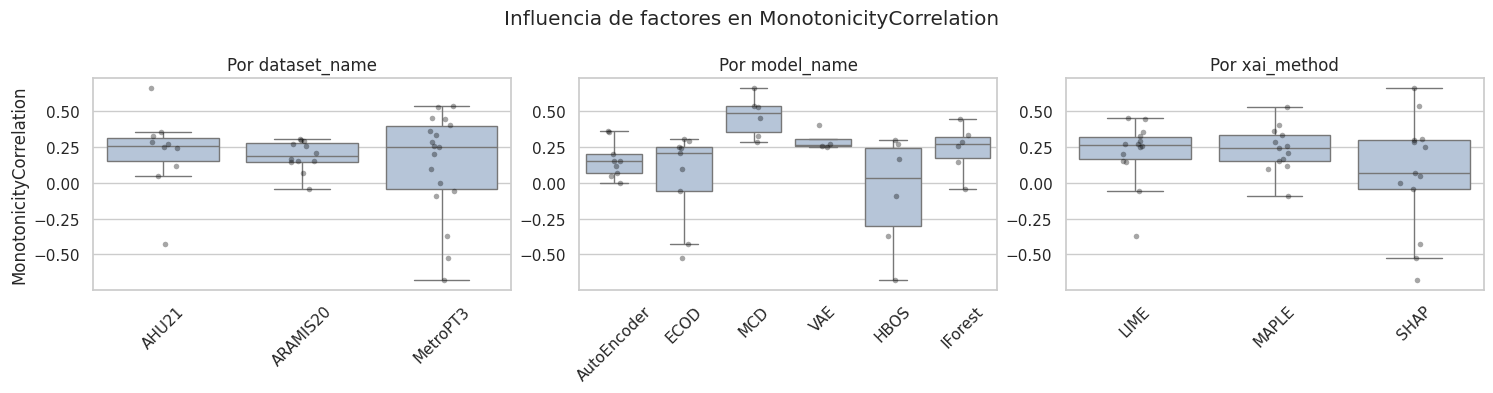

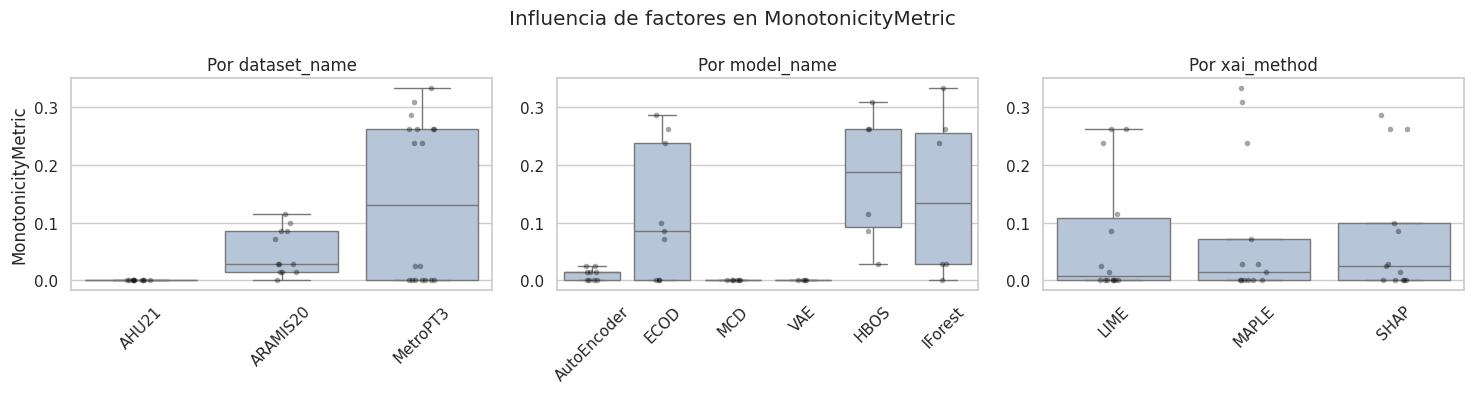

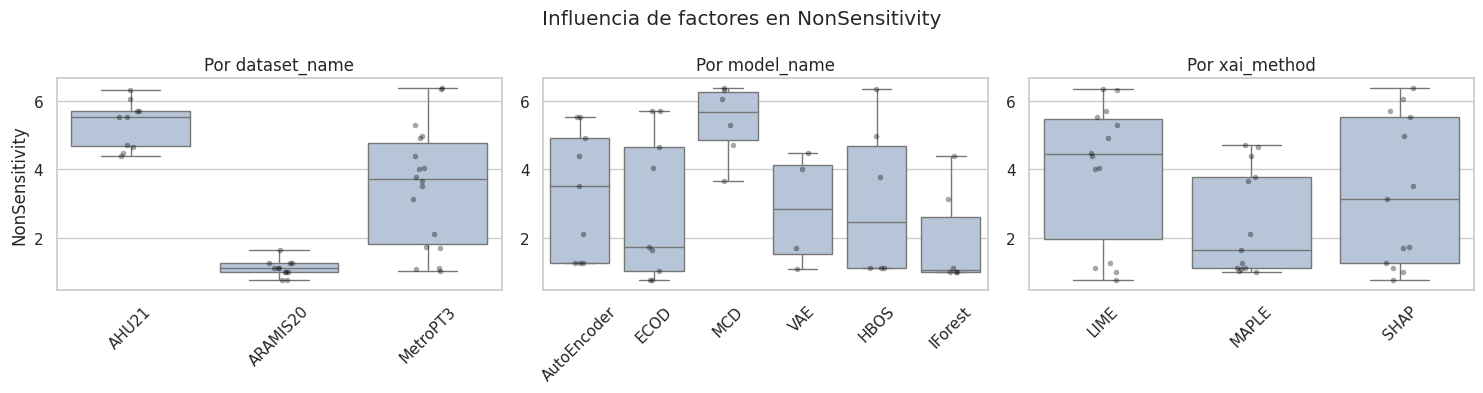

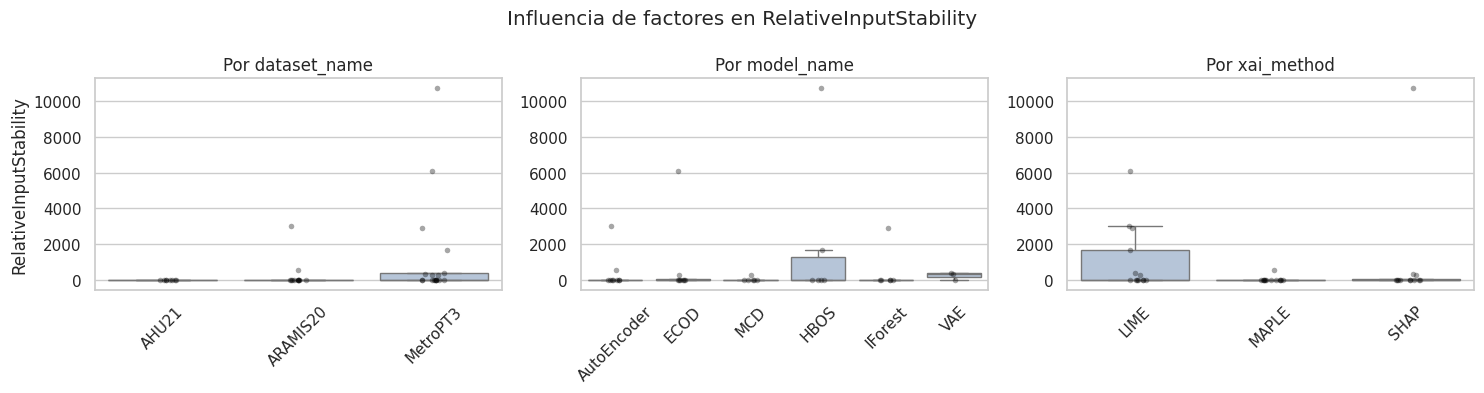

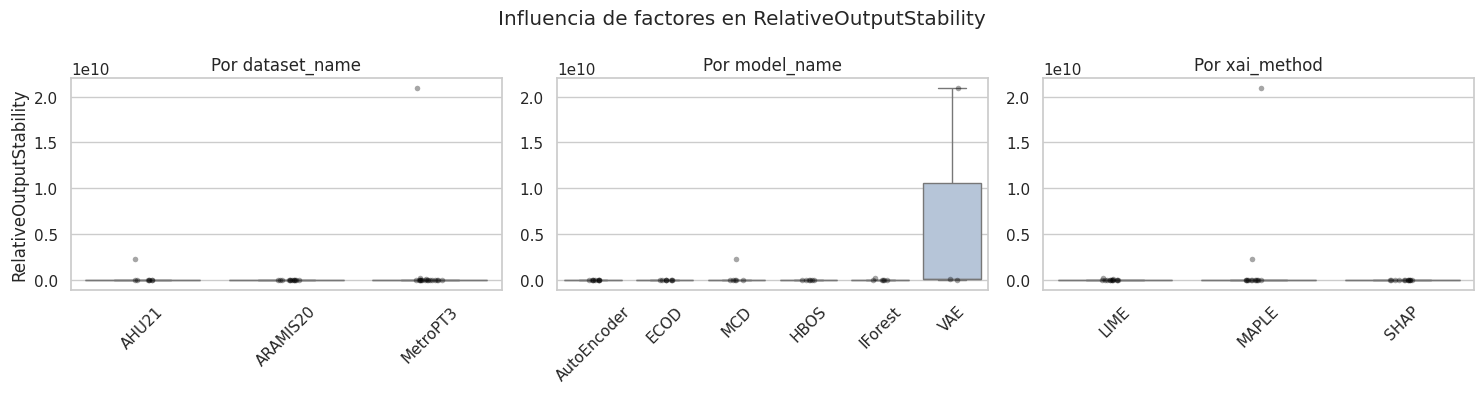

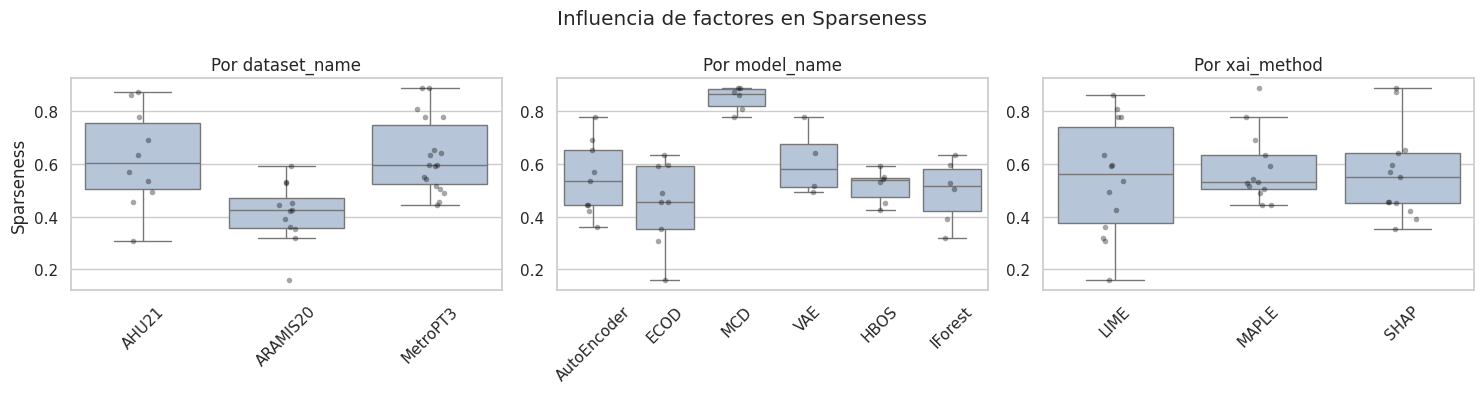

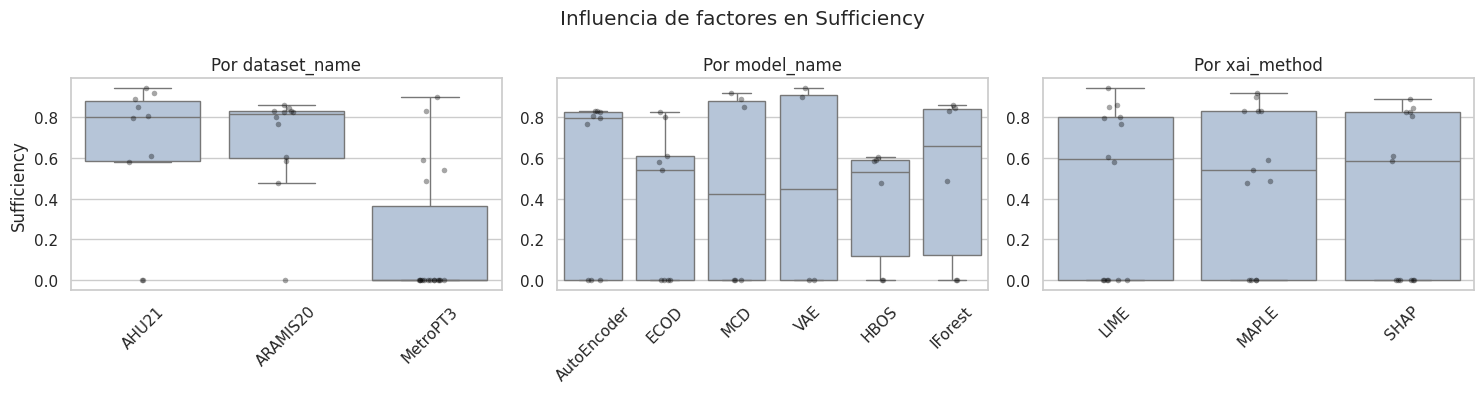

In [23]:
for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        print(f"Saltando {metric}: no tiene variabilidad suficiente.")
        continue

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric}")
    plt.tight_layout()
    plt.savefig(results_dir / f"{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [24]:
kruskal_results = []

for metric in metric_cols:
    if analysis_df[metric].dropna().nunique() <= 1:
        continue

    for factor in factors:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_df = pd.DataFrame(kruskal_results)

kruskal_df = kruskal_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,1829.525704,0.000000e+00,True
30,NonSensitivity,dataset_name,1298.098987,1.322472e-282,True
7,Consistency,model_name,1248.034373,1.156063e-267,True
17,LocalLipschitzEstimate,xai_method,901.199053,2.028206e-196,True
40,Sparseness,model_name,894.619553,3.886549e-191,True
4,Complexity,model_name,737.398472,4.018779e-157,True
39,Sparseness,dataset_name,638.713672,2.018777e-139,True
42,Sufficiency,dataset_name,608.906236,5.993642e-133,True
31,NonSensitivity,model_name,438.683189,1.355713e-92,True
37,RelativeOutputStability,model_name,409.773606,2.320611e-86,True


In [25]:
kruskal_summary = kruskal_df.copy()

kruskal_summary["p_value"] = kruskal_summary["p_value"].round(4)
kruskal_summary["H"] = kruskal_summary["H"].round(3)

kruskal_summary

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,1829.526,0.0000,True
30,NonSensitivity,dataset_name,1298.099,0.0000,True
7,Consistency,model_name,1248.034,0.0000,True
17,LocalLipschitzEstimate,xai_method,901.199,0.0000,True
40,Sparseness,model_name,894.620,0.0000,True
4,Complexity,model_name,737.398,0.0000,True
39,Sparseness,dataset_name,638.714,0.0000,True
42,Sufficiency,dataset_name,608.906,0.0000,True
31,NonSensitivity,model_name,438.683,0.0000,True
37,RelativeOutputStability,model_name,409.774,0.0000,True


In [26]:
kruskal_summary.to_csv(
    results_dir / "kruskal_metric_factors.csv",
    index=False
)

## PCA

In [27]:
from sklearn.decomposition import PCA

In [28]:
metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in global_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

X = analysis_df[valid_metric_cols].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.197495,0.197495
1,PC2,0.136450,0.333945
2,PC3,0.098689,0.432635
3,PC4,0.084388,0.517023
4,PC5,0.076712,0.593735
5,PC6,0.068486,0.662221
6,PC7,0.064759,0.726980
7,PC8,0.063542,0.790522
8,PC9,0.056379,0.846901
9,PC10,0.048011,0.894912


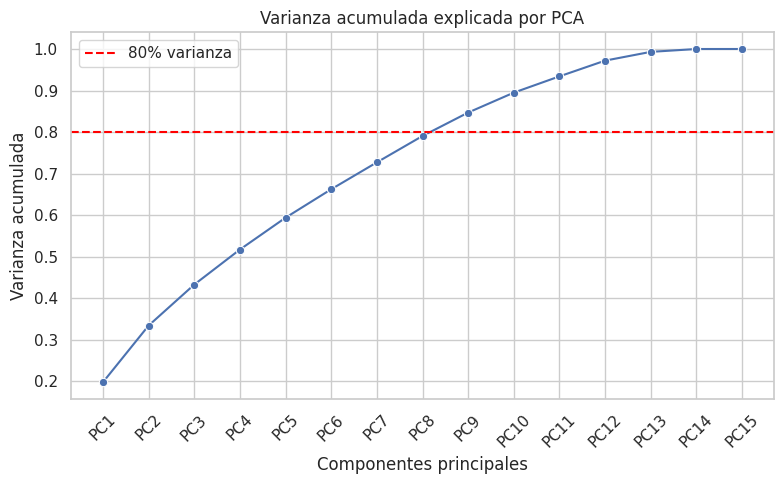

In [29]:
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=explained_variance,
    x="component",
    y="cumulative_variance",
    marker="o"
)

plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
plt.title("Varianza acumulada explicada por PCA")
plt.xlabel("Componentes principales")
plt.ylabel("Varianza acumulada")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=valid_metric_cols,
    columns=[f"PC{i+1}" for i in range(len(valid_metric_cols))]
)

loadings.iloc[:, :3].sort_values("PC1", key=abs, ascending=False)

,PC1,PC2,PC3
Sparseness,0.494933,-0.061051,-0.250430
Complexity,-0.455468,-0.071655,0.269282
Consistency,0.416278,-0.158510,0.299436
MonotonicityCorrelation,0.314581,-0.050470,0.046414
NonSensitivity,0.304481,-0.206681,-0.186647
Faithfulness,-0.271778,0.201604,-0.259818
MaxSensitivity,0.180814,0.638270,0.159759
AvgSensitivity,0.179999,0.638567,0.160243
MonotonicityMetric,-0.177559,0.111771,-0.173003
FaithfulnessEstimate,-0.068912,0.070113,0.345780


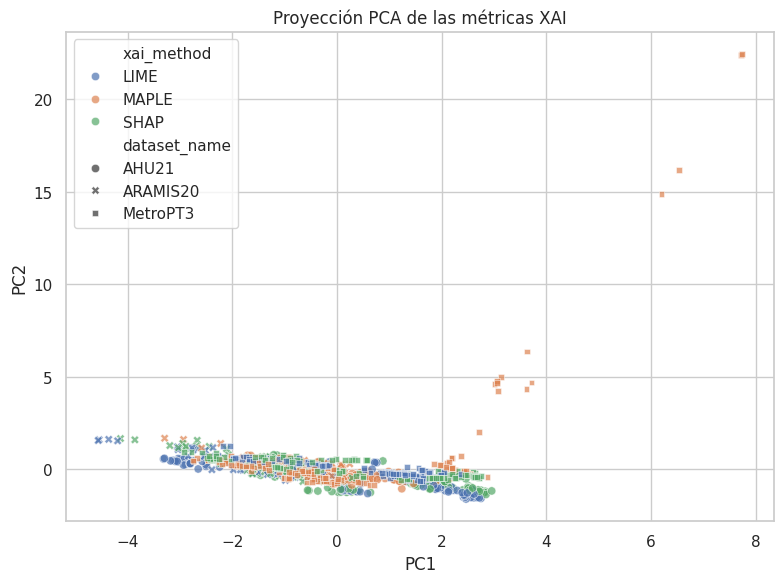

In [31]:
pca_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=X.index
)

pca_df = pca_df.join(analysis_df.loc[X.index, ["dataset_name", "model_name", "xai_method"]])

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="xai_method",
    style="dataset_name",
    alpha=0.7
)

plt.title("Proyección PCA de las métricas XAI")
plt.tight_layout()
plt.savefig(output_dir / "pca_metrics_projection.png", dpi=300, bbox_inches="tight")
plt.show()

# Análisis de métricas agregadas

In [32]:
matrix_path = Path("results/metric_analysis_agg_matrix.csv")
analysis_agg_df = pd.read_csv(matrix_path)

id_cols = ['dataset_name', 'model_name', 'xai_method']

results_dir = Path("results/conclusions_agg_results")
results_dir.mkdir(exist_ok=True)

analysis_agg_df.head()

,dataset_name,model_name,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,LIME,1.130820,0.0,2.344844,0.819048,-0.043856,0.052458,7.829960,1.833814,1.0,0.357878,0.0,5.528571,0.000247,502.620107,-0.159482,0.533692,0.796616
1,AHU21,AutoEncoder,MAPLE,0.810518,0.0,1.827839,0.822222,0.025880,0.047933,3.171403,1.727345,1.0,0.119013,0.0,4.385714,0.175526,235580.702307,0.012383,0.688531,0.000000
2,AHU21,AutoEncoder,SHAP,1.631231,0.0,2.167066,0.819048,0.027710,0.008464,1.898171,3.693749,1.0,0.049265,0.0,5.542857,0.001076,972.891420,0.299500,0.569092,0.807427
3,AHU21,ECOD,LIME,1.181565,0.0,2.675365,0.539048,-0.244549,-0.059335,8.920034,1.638609,1.0,0.249230,0.0,5.700000,0.000335,51.994686,-0.180843,0.308223,0.579370
4,AHU21,ECOD,MAPLE,0.834596,0.0,1.967611,0.570794,0.097456,0.004964,2.105741,2.100510,1.0,0.240288,0.0,4.657143,0.000132,29.033082,0.018716,0.634111,0.000000


## Análisis descriptivo de las métricas

In [33]:
metric_cols_agg = [
    c for c in analysis_agg_df.columns
    if c not in id_cols
]

for col in metric_cols_agg:
    analysis_agg_df[col] = pd.to_numeric(analysis_agg_df[col], errors='coerce')

summary_agg = analysis_agg_df[metric_cols_agg].describe().T

summary_agg['missing'] = analysis_agg_df[metric_cols_agg].isna().sum()
summary_agg['missing_pct'] = analysis_agg_df[metric_cols_agg].isna().mean() * 100
summary_agg['std'] = analysis_agg_df[metric_cols_agg].std()
summary_agg['range'] = summary_agg['max'] - summary_agg['min']
summary_agg['n_unique'] = analysis_agg_df[metric_cols_agg].nunique(dropna=True)

summary_agg = summary_agg[
    ['mean', 'std', 'min', 'max', 'range', 'missing', 'missing_pct', 'n_unique']
].sort_values('std', ascending=False)

summary_agg

,mean,std,min,max,range,missing,missing_pct,n_unique
RelativeOutputStability,6.262686e+08,3.405507e+09,2.903308e+01,2.093812e+10,2.093812e+10,2,5.0,38
MaxSensitivity,4.431592e+02,2.690304e+03,8.099279e-01,1.659008e+04,1.658927e+04,2,5.0,38
RelativeInputStability,6.968241e+02,2.045826e+03,1.321422e-04,1.072343e+04,1.072343e+04,2,5.0,38
AvgSensitivity,3.195775e+02,1.927426e+03,5.987122e-01,1.172666e+04,1.172606e+04,3,7.5,37
LocalLipschitzEstimate,6.099775e+00,3.325616e+00,5.559809e-01,1.286683e+01,1.231085e+01,0,0.0,40
NonSensitivity,3.239762e+00,1.992941e+00,7.571429e-01,6.380952e+00,5.623810e+00,0,0.0,33
Complexity,1.568168e+00,5.400908e-01,-1.000089e-12,2.675365e+00,2.675365e+00,0,0.0,40
Sufficiency,4.495366e-01,3.880478e-01,0.000000e+00,9.428571e-01,9.428571e-01,0,0.0,25
SensitivityN,-1.395422e-01,3.067116e-01,-9.636733e-01,2.995004e-01,1.263174e+00,0,0.0,40
MonotonicityCorrelation,1.707872e-01,2.804240e-01,-6.812231e-01,6.628262e-01,1.344049e+00,0,0.0,40


In [34]:
sns.set_theme(style='whitegrid', context='notebook')

summary_agg_plot = summary_agg.copy()

summary_agg_plot = summary_agg_plot.drop(index=global_metrics, errors='ignore')

summary_agg_plot = summary_agg_plot.sort_values('std', ascending=False)

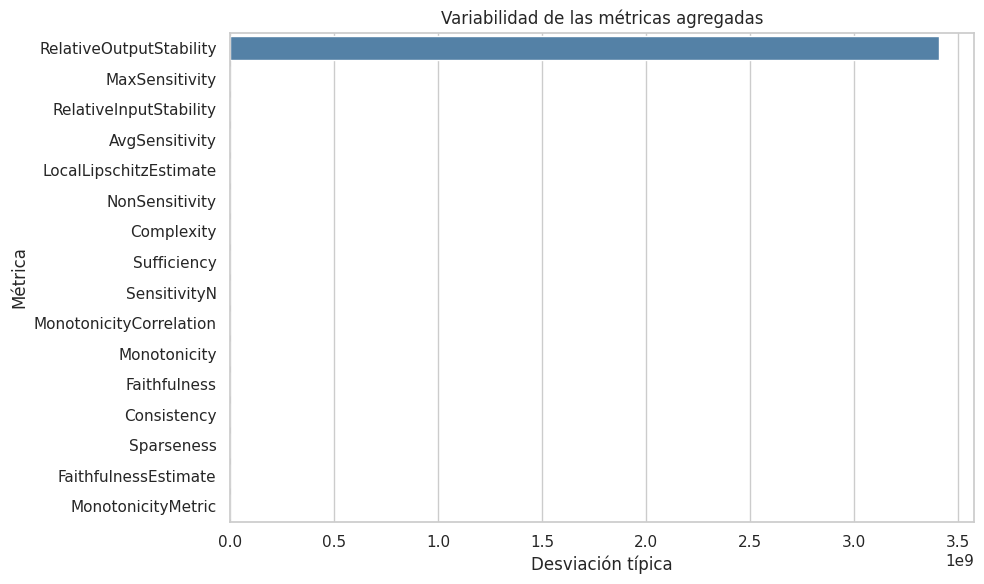

In [35]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

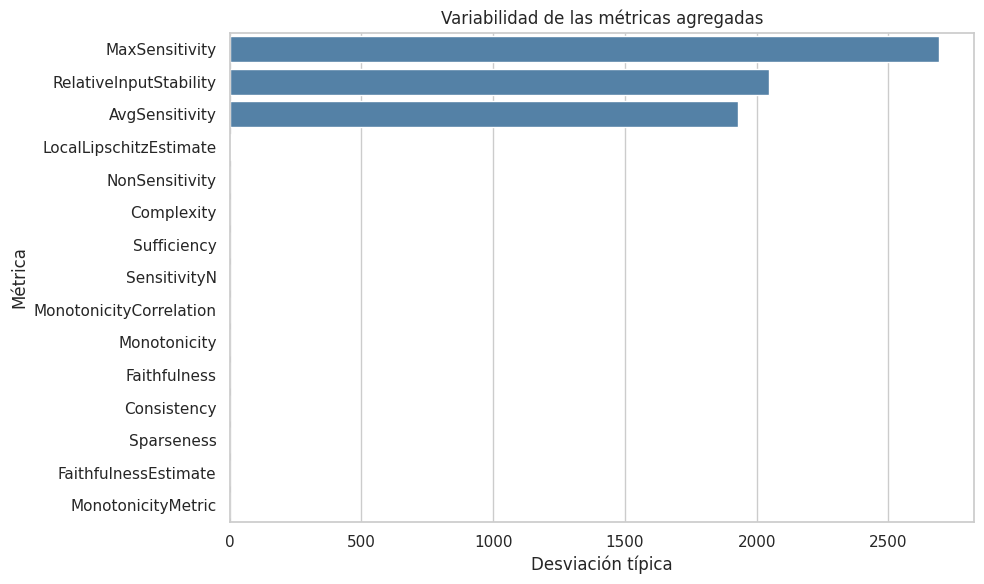

In [36]:
summary_plot_agg = summary_agg[
    summary_agg["n_unique"] > 1
].copy()

summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg_aux.reset_index(),
    y="index",
    x="std",
    color="steelblue"
)
plt.title("Variabilidad de las métricas agregadas")
plt.xlabel("Desviación típica")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_std.png", dpi=300, bbox_inches="tight")
plt.show()

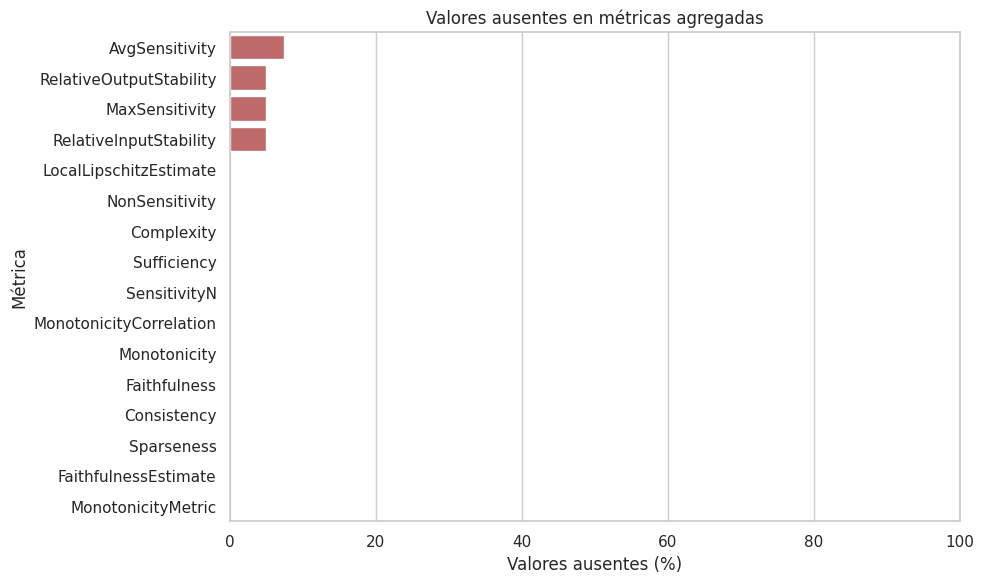

In [37]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_plot_agg.sort_values("missing_pct", ascending=False).reset_index(),
    y="index",
    x="missing_pct",
    color="indianred"
)
plt.title("Valores ausentes en métricas agregadas")
plt.xlabel("Valores ausentes (%)")
plt.ylabel("Métrica")
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_missing.png", dpi=300, bbox_inches="tight")
plt.show()

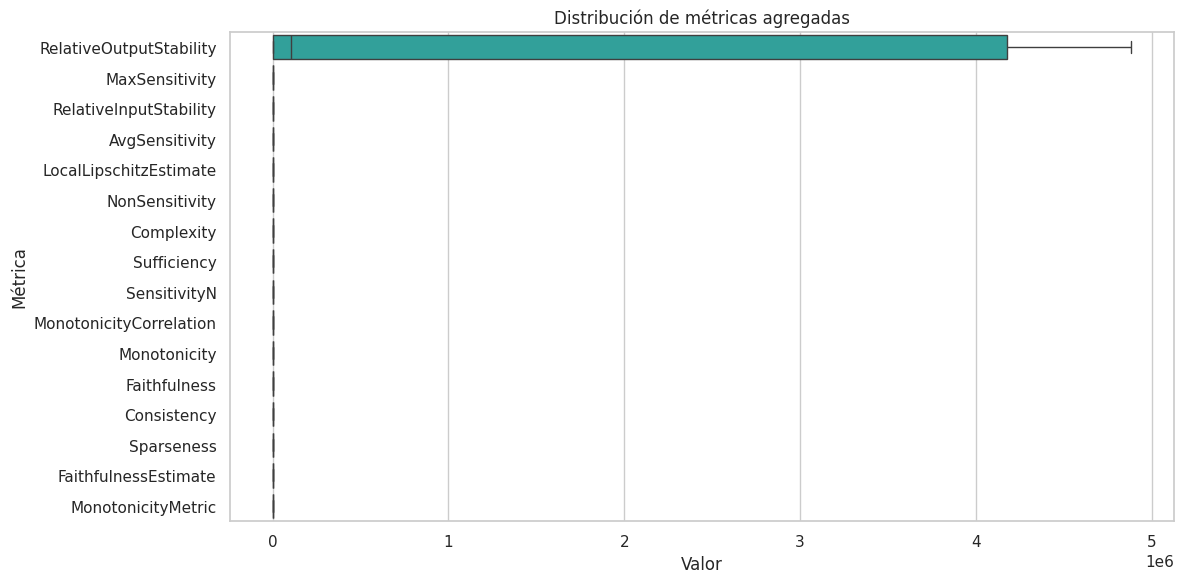

In [38]:
plot_long_agg = analysis_agg_df[summary_plot_agg.index].melt(
    var_name="metric",
    value_name="value"
).dropna()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

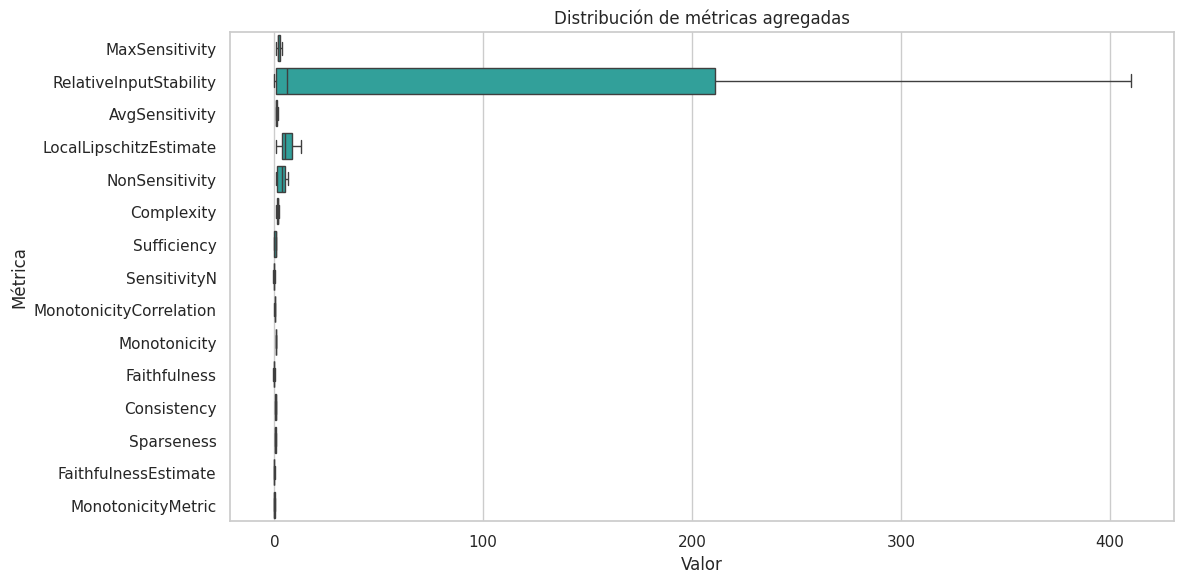

In [39]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

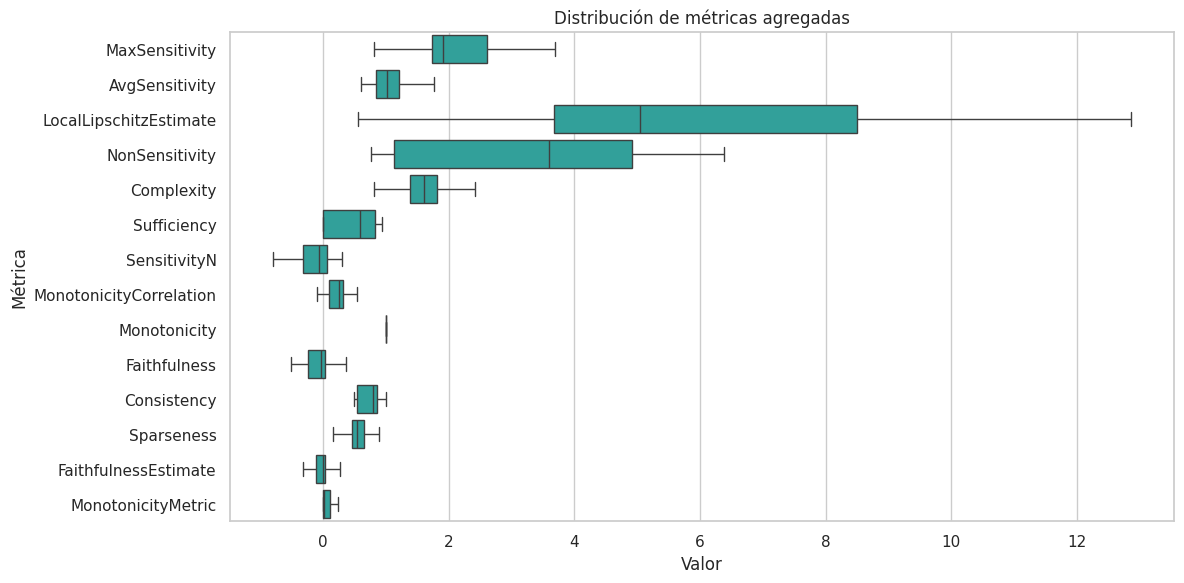

In [40]:
summary_plot_agg_aux = summary_plot_agg.drop(index=['RelativeOutputStability', 'RelativeInputStability'])

plot_long_agg = analysis_agg_df[summary_plot_agg_aux.index].melt(
    var_name="metric",
    value_name="value"
).dropna()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_long_agg,
    x="value",
    y="metric",
    color="lightseagreen",
    showfliers=False
)
plt.title("Distribución de métricas agregadas")
plt.xlabel("Valor")
plt.ylabel("Métrica")
plt.tight_layout()
plt.savefig(results_dir / "agg_metric_distributions.png", dpi=300, bbox_inches="tight")
plt.show()

## Correlación entre métricas

In [41]:
valid_metric_cols_agg = [
    c for c in metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

excluded_constant_agg = [
    c for c in metric_cols_agg
    if c not in valid_metric_cols_agg
]

print("Métricas excluidas por ser constantes o no tener variación:")
print(excluded_constant_agg)

X_agg = analysis_agg_df[valid_metric_cols_agg]

corr_agg = X_agg.corr(
    method="spearman",
    min_periods=5
)

corr_agg

Métricas excluidas por ser constantes o no tener variación:
['Completeness']


,AvgSensitivity,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,LocalLipschitzEstimate,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
AvgSensitivity,1.000000,-0.215742,0.159568,-0.143907,-0.006638,0.004267,0.725462,0.176198,0.194168,-0.039359,0.484791,-0.082504,0.333096,-0.137743,0.371503,-0.014217
Complexity,-0.215742,1.000000,-0.388307,0.116323,0.387617,0.168856,-0.354415,0.005228,-0.331144,0.017335,-0.097142,-0.152643,-0.462086,0.292495,-0.641839,0.285814
Consistency,0.159568,-0.388307,1.000000,-0.323731,-0.057621,-0.244302,0.205309,-0.365827,0.351742,-0.675158,0.222045,-0.113622,0.403818,0.017296,0.449594,0.277649
Faithfulness,-0.143907,0.116323,-0.323731,1.000000,0.354597,-0.269043,0.013240,0.275664,-0.089118,0.151779,-0.235769,0.001204,-0.154831,0.091932,-0.075797,-0.083088
FaithfulnessEstimate,-0.006638,0.387617,-0.057621,0.354597,1.000000,-0.223265,0.034030,0.086900,-0.029456,-0.031813,-0.108874,-0.135354,0.069701,0.405253,-0.172233,0.320232
LocalLipschitzEstimate,0.004267,0.168856,-0.244302,-0.269043,-0.223265,1.000000,-0.346318,-0.000541,-0.068293,0.224861,0.051152,0.447861,-0.025933,-0.069231,-0.316135,-0.049155
MaxSensitivity,0.725462,-0.354415,0.205309,0.013240,0.034030,-0.346318,1.000000,0.333729,0.074516,0.023003,0.328662,-0.192691,0.114564,-0.050005,0.465149,-0.089509
Monotonicity,0.176198,0.005228,-0.365827,0.275664,0.086900,-0.000541,0.333729,1.000000,-0.152706,0.333159,0.071252,-0.253634,-0.431623,0.009736,-0.107453,-0.084781
MonotonicityCorrelation,0.194168,-0.331144,0.351742,-0.089118,-0.029456,-0.068293,0.074516,-0.152706,1.000000,-0.357335,0.041016,-0.269067,0.279133,-0.057036,0.285366,0.178294
MonotonicityMetric,-0.039359,0.017335,-0.675158,0.151779,-0.031813,0.224861,0.023003,0.333159,-0.357335,1.000000,-0.375110,0.317371,-0.196208,-0.221315,-0.274206,-0.304974


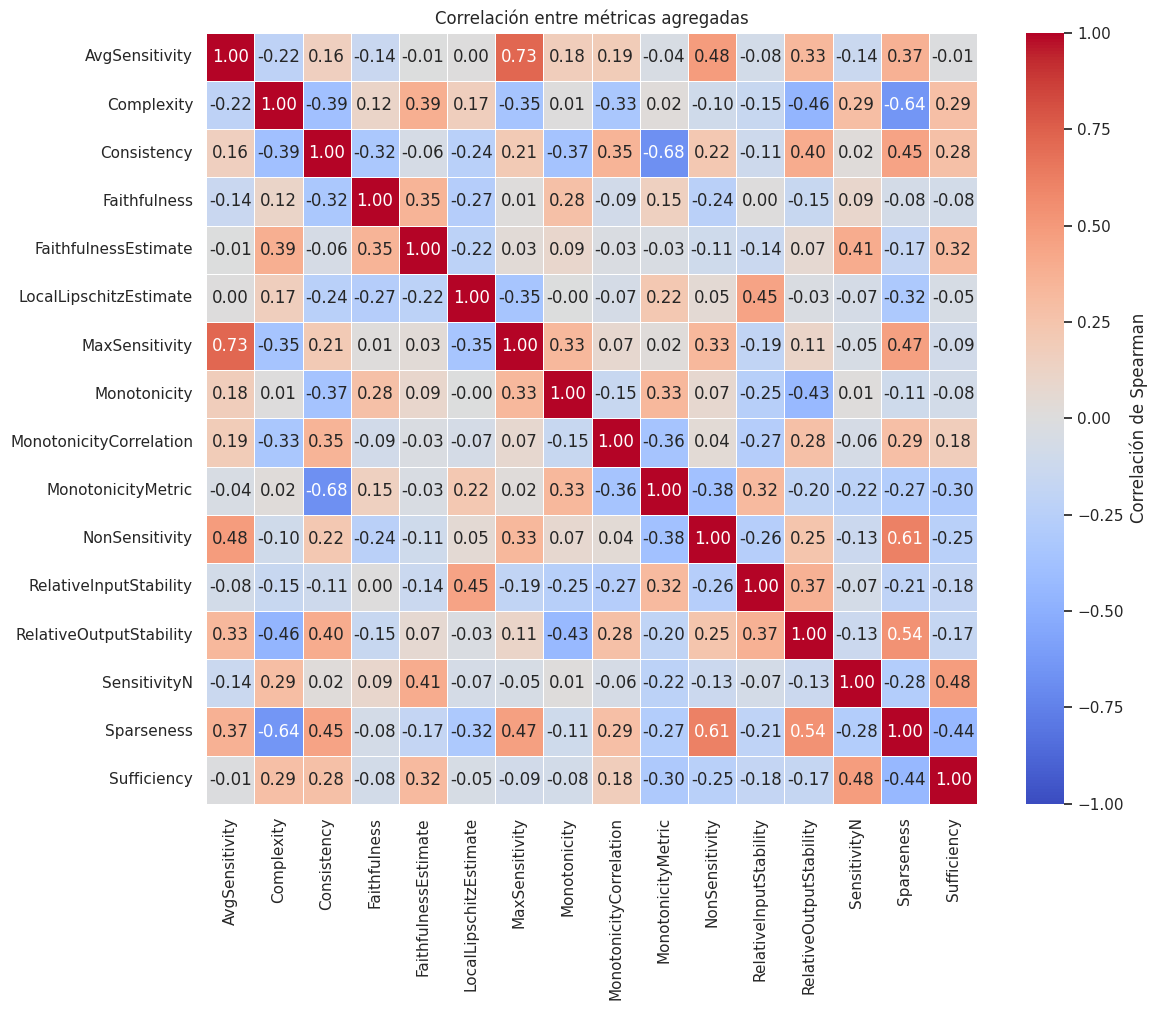

In [42]:
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_agg,
    vmin=-1,
    vmax=1,
    center=0,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Correlación de Spearman"}
)

plt.title("Correlación entre métricas agregadas")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(results_dir / "agg_correlation_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

In [43]:
corr_pairs_agg = (
    corr_agg.where(
        np.triu(np.ones(corr_agg.shape), k=1).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs_agg.columns = ["metric_1", "metric_2", "spearman_corr"]
corr_pairs_agg["abs_corr"] = corr_pairs_agg["spearman_corr"].abs()

strong_corr_agg = corr_pairs_agg[
    corr_pairs_agg["abs_corr"] > 0.6
].sort_values("abs_corr", ascending=False)

strong_corr_agg

,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.725462,0.725462
35,Consistency,MonotonicityMetric,-0.675158,0.675158
27,Complexity,Sparseness,-0.641839,0.641839
108,NonSensitivity,Sparseness,0.610446,0.610446


## Clustering jerárquico de métricas

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

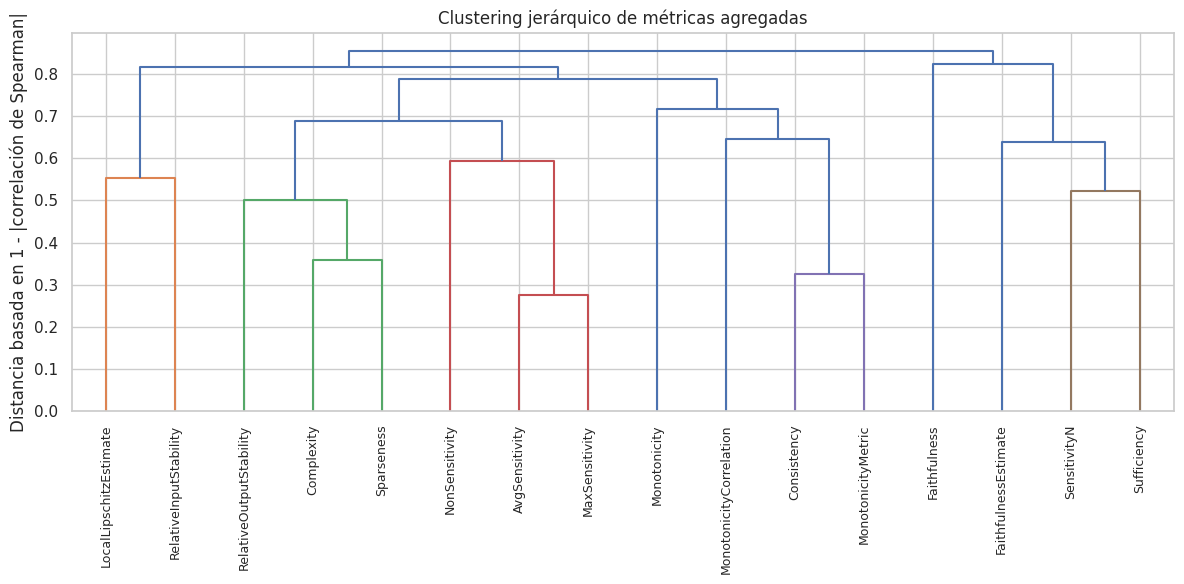

In [45]:
corr_cluster_agg = corr_agg.copy()

corr_cluster_agg = corr_cluster_agg.dropna(axis=0, how="all").dropna(axis=1, how="all")

valid_metrics_agg = corr_cluster_agg.index.intersection(corr_cluster_agg.columns)
corr_cluster_agg = corr_cluster_agg.loc[valid_metrics_agg, valid_metrics_agg]

corr_cluster_agg = corr_cluster_agg.fillna(0)

distance_agg = 1 - corr_cluster_agg.abs()
np.fill_diagonal(distance_agg.values, 0)

linkage_matrix_agg = linkage(
    squareform(distance_agg),
    method="average"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linkage_matrix_agg,
    labels=corr_cluster_agg.columns,
    leaf_rotation=90,
    leaf_font_size=9
)

plt.title("Clustering jerárquico de métricas agregadas")
plt.ylabel("Distancia basada en 1 - |correlación de Spearman|")
plt.tight_layout()
plt.savefig(results_dir / "agg_dendrogram_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

## Influencia de dataset, modelo y método XAI

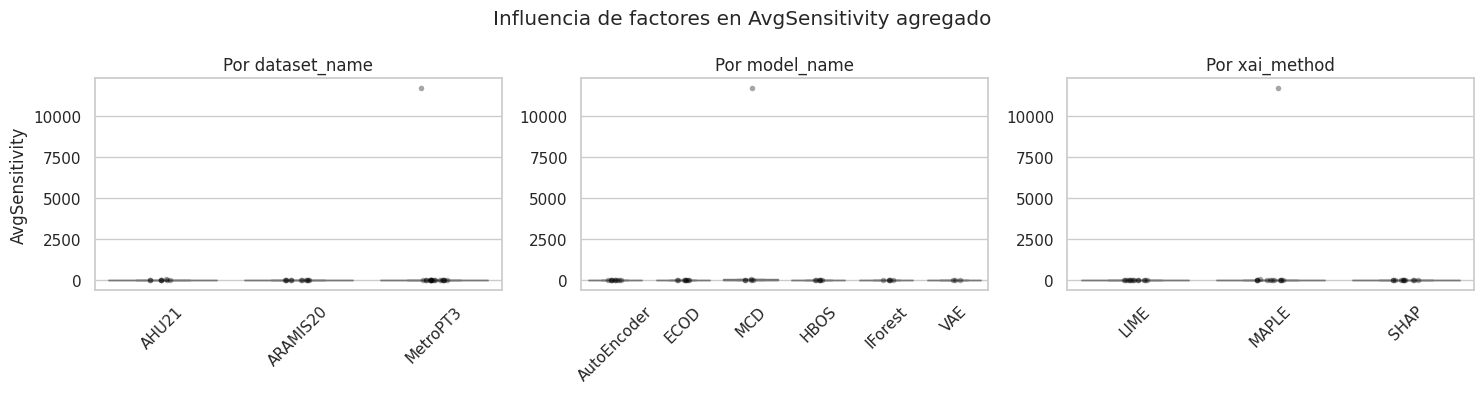

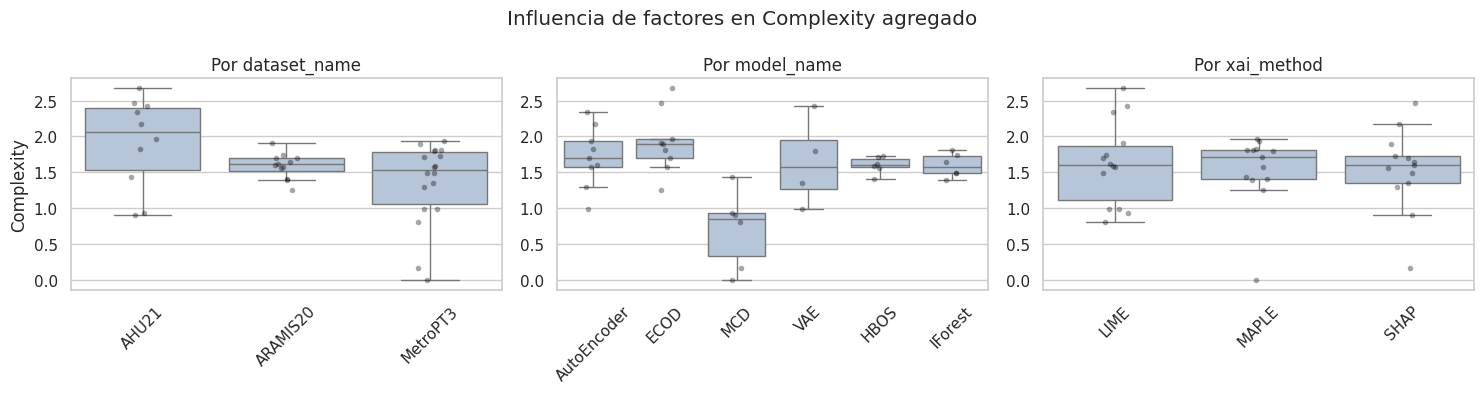

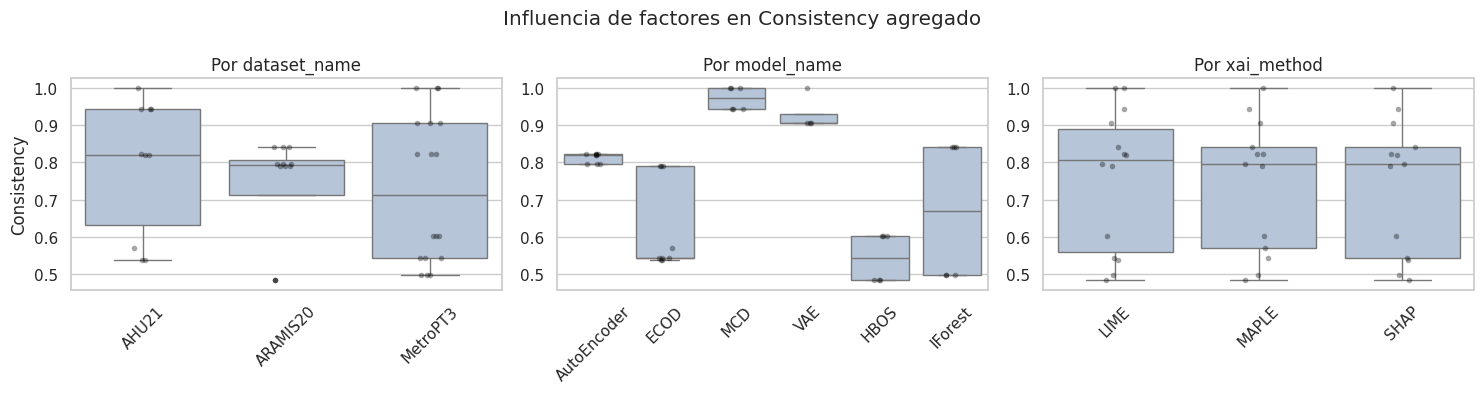

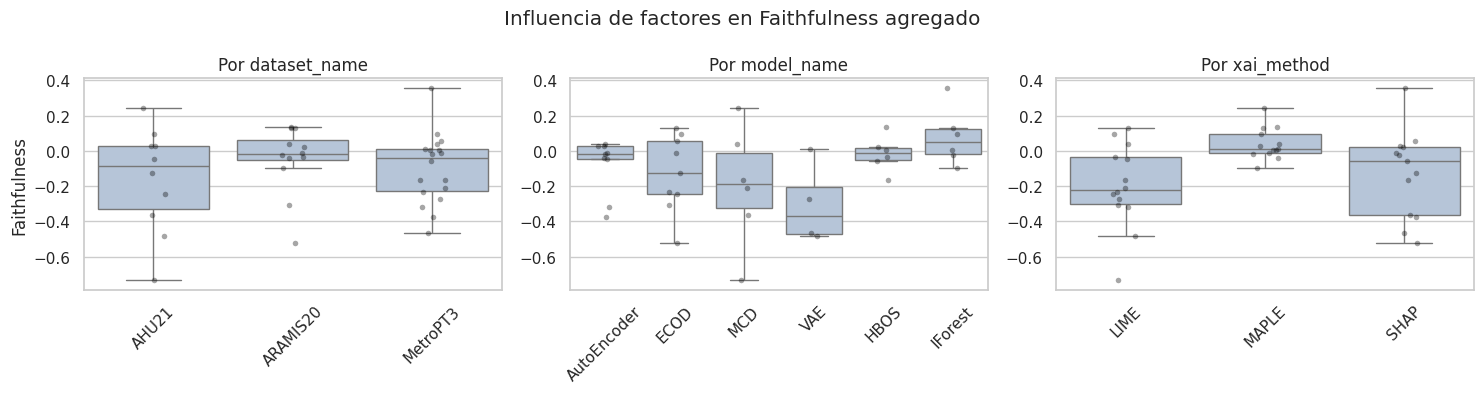

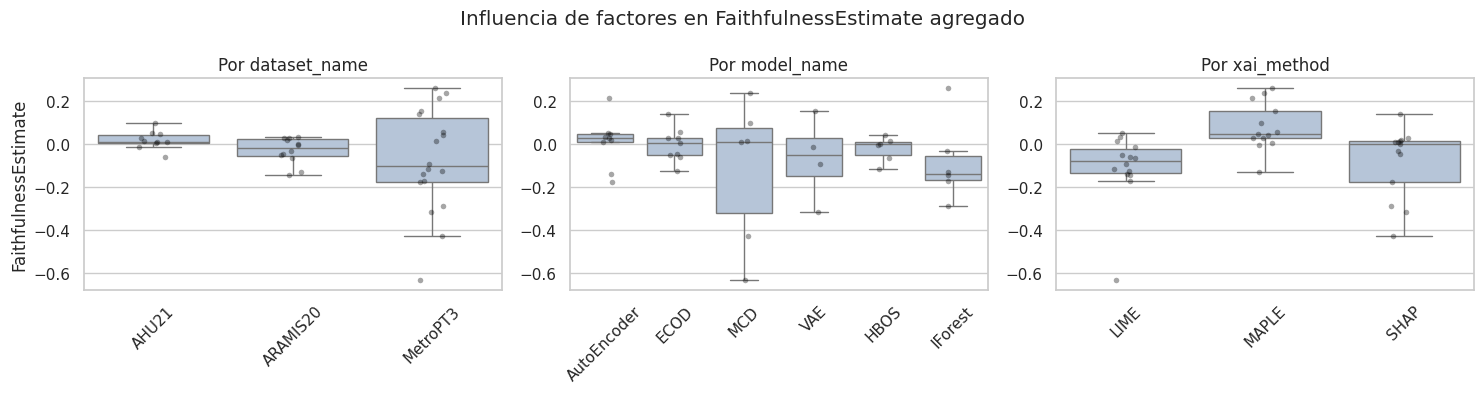

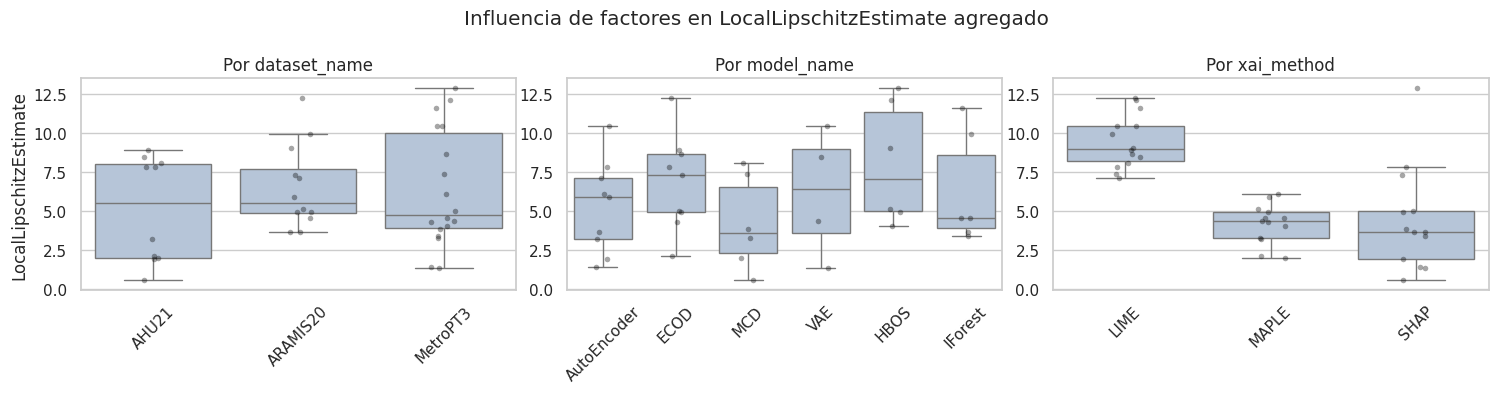

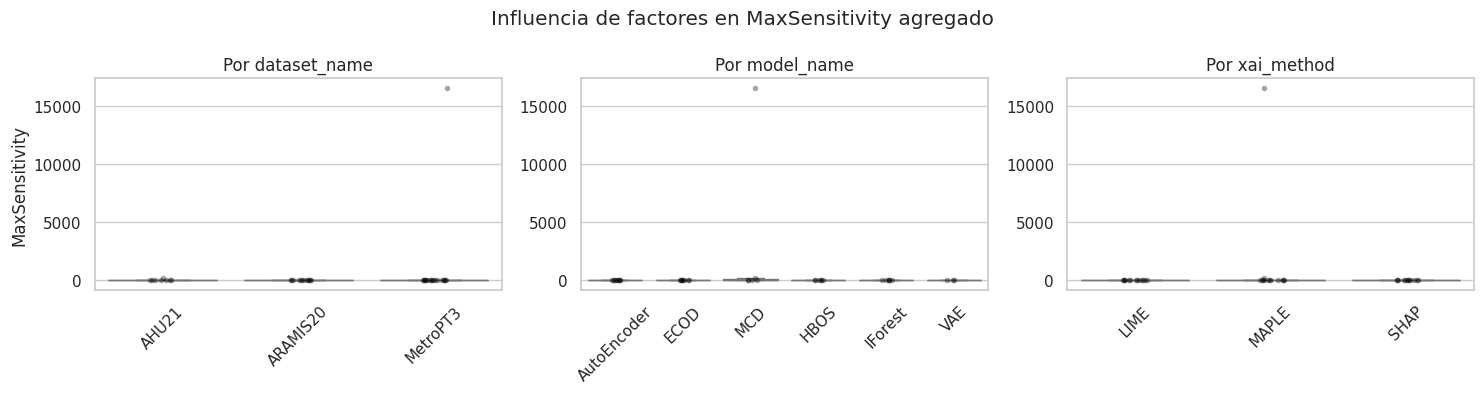

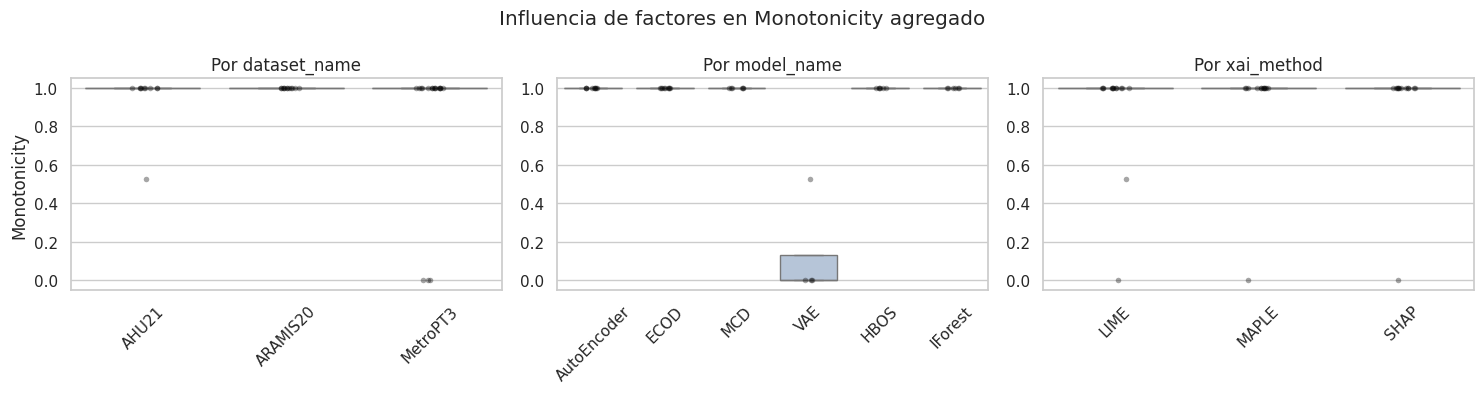

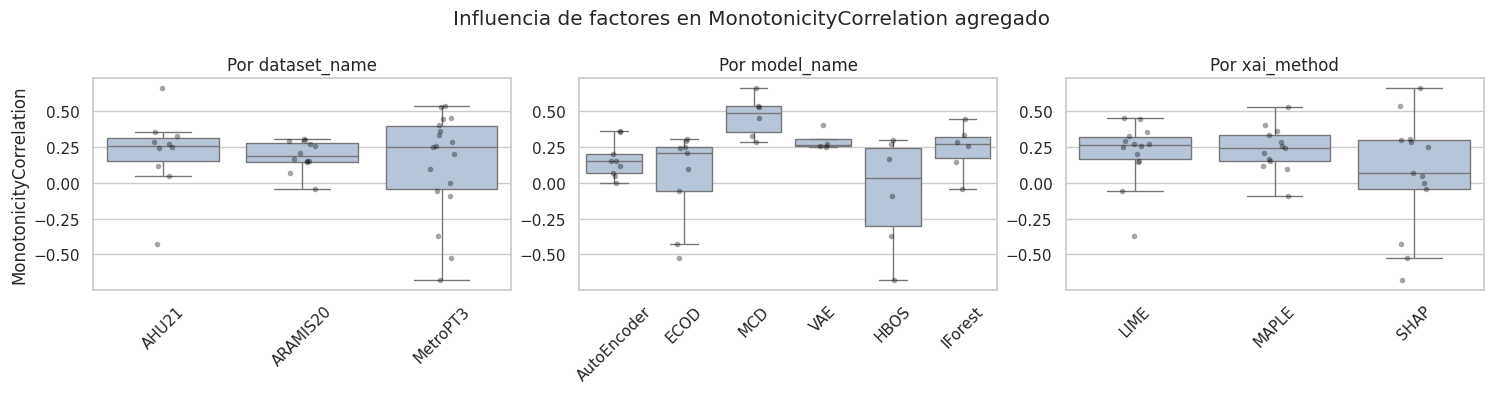

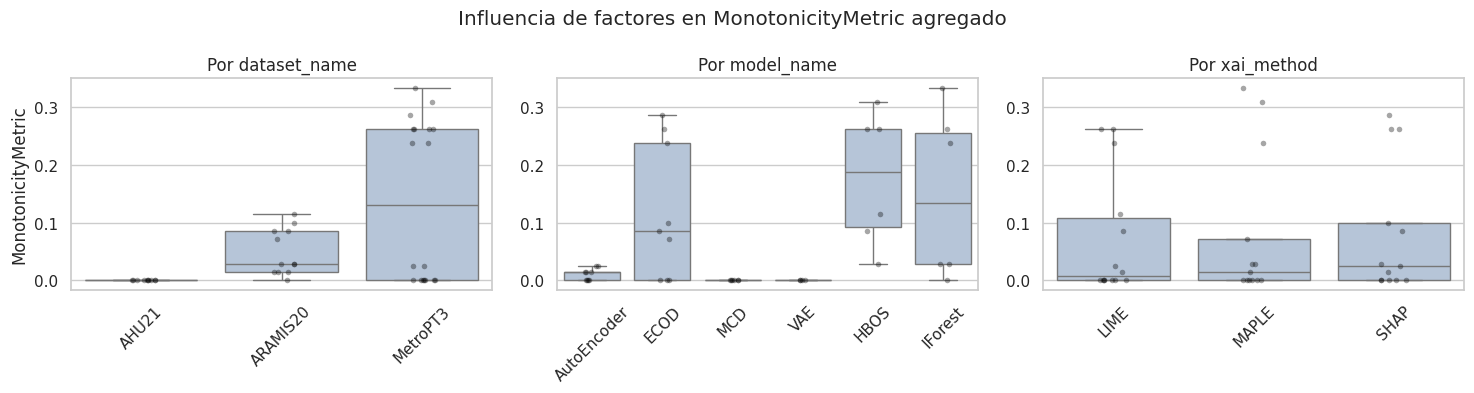

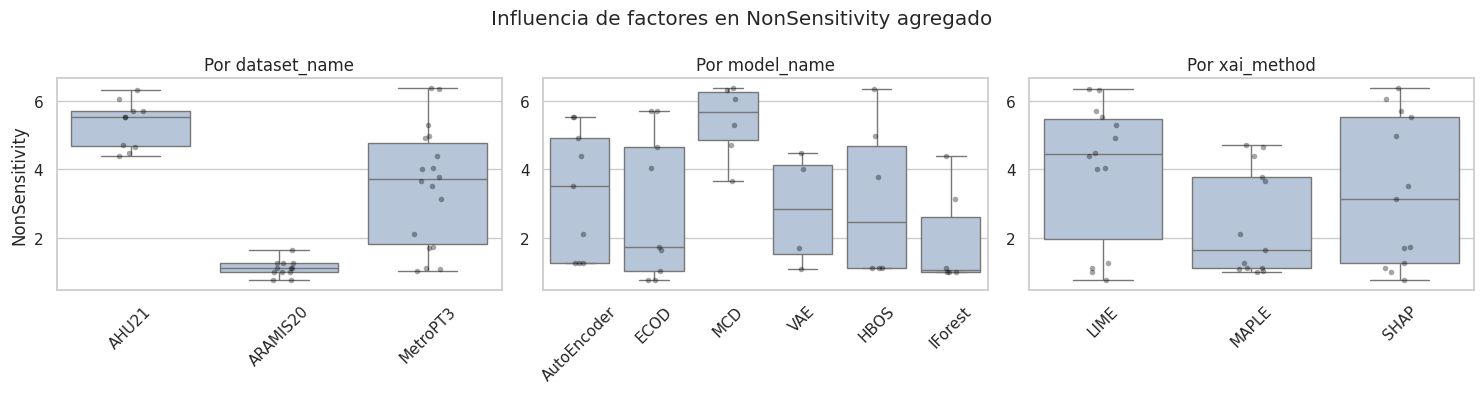

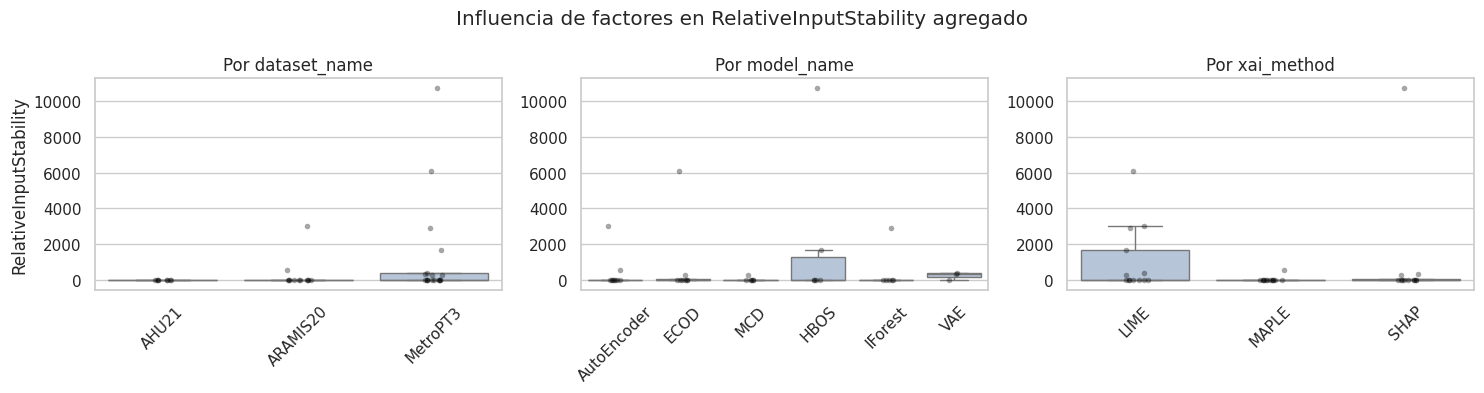

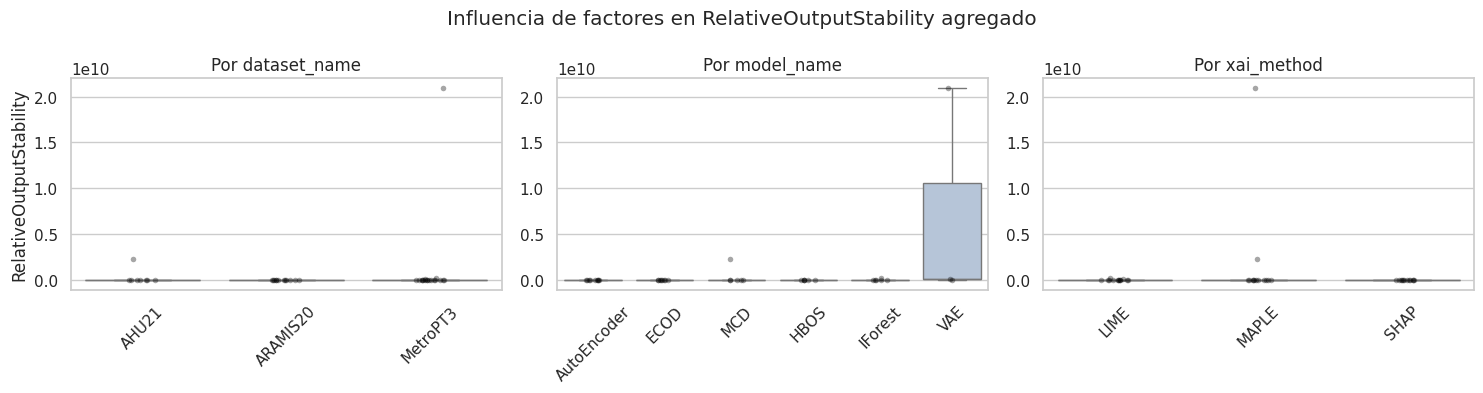

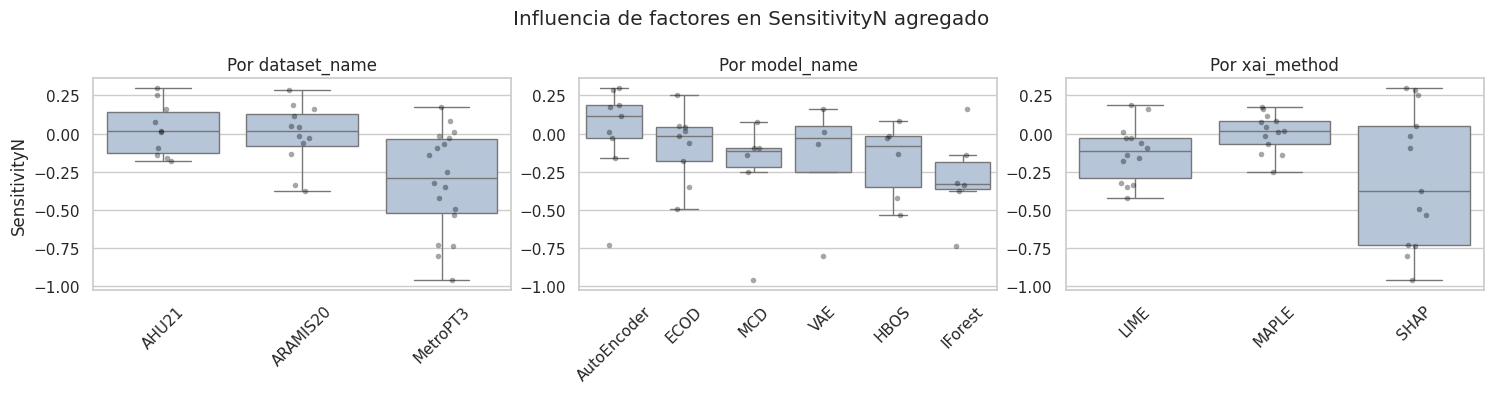

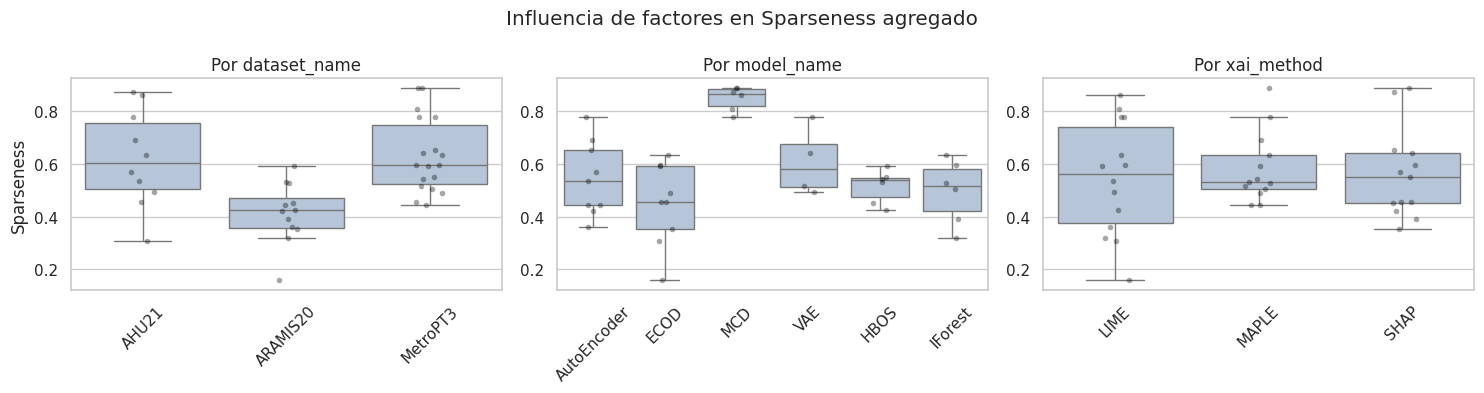

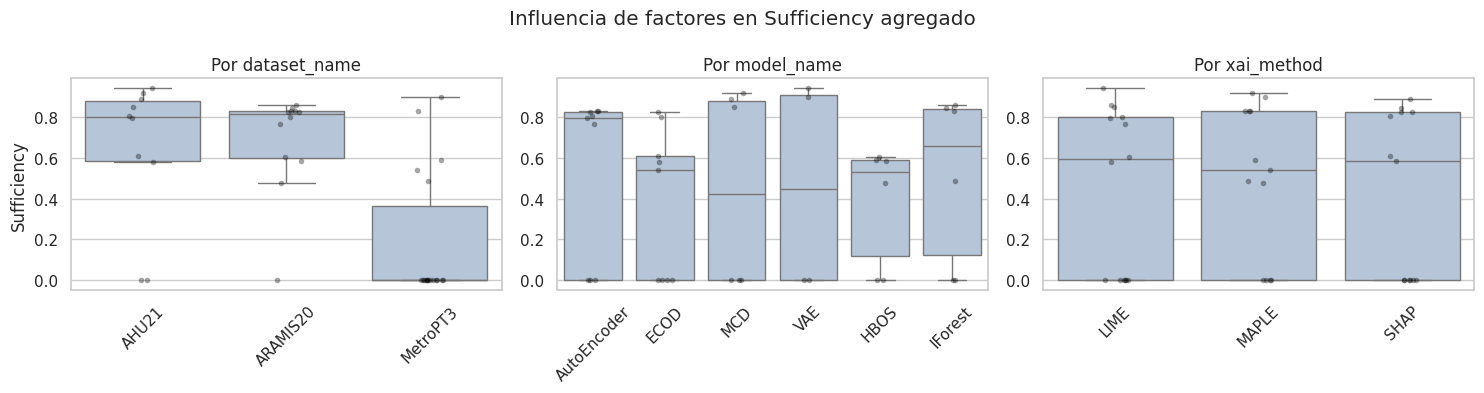

In [46]:
factors_agg = ["dataset_name", "model_name", "xai_method"]

selected_metrics_agg = [
    c for c in valid_metric_cols_agg
    if analysis_agg_df[c].dropna().nunique() > 1
]

for metric in selected_metrics_agg:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, factor in zip(axes, factors_agg):
        plot_df = analysis_agg_df[[factor, metric]].dropna()

        sns.boxplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="lightsteelblue",
            showfliers=False
        )

        sns.stripplot(
            data=plot_df,
            x=factor,
            y=metric,
            ax=ax,
            color="black",
            alpha=0.35,
            size=4,
            jitter=True
        )

        ax.set_title(f"Por {factor}")
        ax.set_xlabel("")
        ax.set_ylabel(metric if factor == factors_agg[0] else "")
        ax.tick_params(axis="x", rotation=45)

    fig.suptitle(f"Influencia de factores en {metric} agregado")
    plt.tight_layout()
    plt.savefig(results_dir / f"agg_{metric}_factors_boxplots.png", dpi=300, bbox_inches="tight")
    plt.show()

In [47]:
kruskal_results_agg = []

for metric in selected_metrics_agg:
    for factor in factors_agg:
        groups = [
            group[metric].dropna().values
            for _, group in analysis_agg_df.groupby(factor)
        ]

        groups = [g for g in groups if len(g) > 0]

        if len(groups) > 1:
            stat, p_value = kruskal(*groups)

            kruskal_results_agg.append({
                "metric": metric,
                "factor": factor,
                "H": stat,
                "p_value": p_value,
                "significant_0.05": p_value < 0.05
            })

kruskal_agg_df = pd.DataFrame(kruskal_results_agg)

kruskal_agg_df = kruskal_agg_df.sort_values(
    ["p_value", "metric", "factor"],
    ascending=[True, True, True]
)

kruskal_agg_df

,metric,factor,H,p_value,significant_0.05
22,Monotonicity,model_name,38.918919,2.465768e-07,True
30,NonSensitivity,dataset_name,23.582750,7.569566e-06,True
17,LocalLipschitzEstimate,xai_method,21.895417,1.759830e-05,True
7,Consistency,model_name,29.396016,1.938718e-05,True
33,RelativeInputStability,dataset_name,16.386752,2.764789e-04,True
28,MonotonicityMetric,model_name,21.968028,5.309765e-04,True
42,Sparseness,dataset_name,14.784065,6.161424e-04,True
14,FaithfulnessEstimate,xai_method,13.335366,1.271341e-03,True
45,Sufficiency,dataset_name,13.045342,1.469739e-03,True
27,MonotonicityMetric,dataset_name,13.013724,1.493158e-03,True


# Analisis de métricas por modelo y método

In [48]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import kruskal
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set_theme(style="whitegrid", context="notebook")

matrix_path = Path("results/metric_analysis_matrix.csv")
results_dir = Path("results/conclusions_obs_results")
results_dir.mkdir(parents=True, exist_ok=True)

analysis_df = pd.read_csv(matrix_path)

id_cols = ["dataset_name", "model_name", "observation", "xai_method"]
excluded_metrics = ["SensitivityN", "Completeness"]

metric_cols = [
    c for c in analysis_df.columns
    if c not in id_cols and c not in excluded_metrics
]

for col in metric_cols:
    analysis_df[col] = pd.to_numeric(analysis_df[col], errors="coerce")

valid_metric_cols = [
    c for c in metric_cols
    if analysis_df[c].dropna().nunique() > 1
]

analysis_df.head()

,dataset_name,model_name,observation,xai_method,AvgSensitivity,Completeness,Complexity,Consistency,Faithfulness,FaithfulnessEstimate,...,MaxSensitivity,Monotonicity,MonotonicityCorrelation,MonotonicityMetric,NonSensitivity,RelativeInputStability,RelativeOutputStability,SensitivityN,Sparseness,Sufficiency
0,AHU21,AutoEncoder,10163,LIME,0.996399,False,2.322274,0.888889,0.299162,0.363635,...,1.930040,1.0,0.357843,0.0,3.0,NaN,NaN,NaN,0.542530,0.904762
1,AHU21,AutoEncoder,10163,MAPLE,0.267372,False,1.740961,0.870370,-0.014254,-0.374276,...,1.361618,1.0,0.232843,0.0,2.0,NaN,NaN,NaN,0.720109,0.000000
2,AHU21,AutoEncoder,10163,SHAP,1.599045,False,2.389480,0.888889,0.449412,0.089394,...,3.593856,1.0,-0.181373,0.0,3.0,NaN,NaN,NaN,0.514415,0.942308
3,AHU21,AutoEncoder,10164,LIME,1.029142,False,2.346466,0.888889,0.316009,0.352108,...,1.915129,1.0,0.338235,0.0,3.0,NaN,NaN,NaN,0.533315,0.923077
4,AHU21,AutoEncoder,10164,MAPLE,0.261949,False,1.766674,0.870370,-0.008365,-0.364325,...,1.445715,1.0,0.215686,0.0,2.0,NaN,NaN,NaN,0.711035,0.000000


In [49]:
def safe_name(value):
    value = str(value)
    value = re.sub(r"[^a-zA-Z0-9_-]+", "_", value)
    return value.strip("_")


def run_metric_study_by_group(
    df,
    group_col,
    metric_cols,
    output_dir,
    remaining_factors=None,
    min_periods_corr=20,
    show_plots=False
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    results = {}

    for group_value, group_df in df.groupby(group_col):
        group_name = safe_name(group_value)
        group_dir = output_dir / f"{group_col}_{group_name}"
        group_dir.mkdir(parents=True, exist_ok=True)

        print(f"\n===== {group_col}: {group_value} =====")
        print(f"Filas: {len(group_df)}")

        valid_cols = [
            c for c in metric_cols
            if group_df[c].dropna().nunique() > 1
        ]

        excluded_cols = [
            c for c in metric_cols
            if c not in valid_cols
        ]

        print("Metricas validas:", valid_cols)
        print("Metricas excluidas:", excluded_cols)

        group_results = {}

        # A. Analisis descriptivo
        summary = group_df[metric_cols].describe().T
        summary["missing"] = group_df[metric_cols].isna().sum()
        summary["missing_pct"] = group_df[metric_cols].isna().mean() * 100
        summary["std"] = group_df[metric_cols].std()
        summary["range"] = summary["max"] - summary["min"]
        summary["n_unique"] = group_df[metric_cols].nunique(dropna=True)

        summary = summary[
            ["mean", "std", "min", "max", "range", "missing", "missing_pct", "n_unique"]
        ].sort_values("std", ascending=False)

        summary.to_csv(group_dir / "summary.csv")
        group_results["summary"] = summary

        # Grafica de variabilidad
        summary_plot = summary[summary["n_unique"] > 1].copy()

        if len(summary_plot) > 0:
            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=summary_plot.reset_index(),
                y="index",
                x="std",
                color="steelblue"
            )
            plt.title(f"Variabilidad de metricas - {group_col}: {group_value}")
            plt.xlabel("Desviacion tipica")
            plt.ylabel("Metrica")
            plt.tight_layout()
            plt.savefig(group_dir / "metric_std.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

        # B. Correlacion
        if len(valid_cols) >= 2:
            corr = group_df[valid_cols].corr(
                method="spearman",
                min_periods=min_periods_corr
            )

            corr.to_csv(group_dir / "correlation.csv")
            group_results["corr"] = corr

            plt.figure(figsize=(12, 10))
            sns.heatmap(
                corr,
                vmin=-1,
                vmax=1,
                center=0,
                cmap="coolwarm",
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                square=True,
                cbar_kws={"label": "Correlacion de Spearman"}
            )
            plt.title(f"Correlacion entre metricas - {group_col}: {group_value}")
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.savefig(group_dir / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            corr_pairs = (
                corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                .stack()
                .reset_index()
            )

            corr_pairs.columns = ["metric_1", "metric_2", "spearman_corr"]
            corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()
            corr_pairs = corr_pairs.sort_values("abs_corr", ascending=False)

            strong_corr = corr_pairs[corr_pairs["abs_corr"] > 0.6]

            corr_pairs.to_csv(group_dir / "correlation_pairs.csv", index=False)
            strong_corr.to_csv(group_dir / "strong_correlations.csv", index=False)

            group_results["corr_pairs"] = corr_pairs
            group_results["strong_corr"] = strong_corr

            print("Correlaciones fuertes |rho| > 0.6:")
            display(strong_corr)

            # C. Clustering jerarquico
            corr_cluster = corr.dropna(axis=0, how="all").dropna(axis=1, how="all")
            valid_metrics = corr_cluster.index.intersection(corr_cluster.columns)
            corr_cluster = corr_cluster.loc[valid_metrics, valid_metrics].fillna(0)

            if len(corr_cluster) >= 3:
                distance = 1 - corr_cluster.abs()
                np.fill_diagonal(distance.values, 0)

                linkage_matrix = linkage(
                    squareform(distance),
                    method="average"
                )

                plt.figure(figsize=(12, 6))
                dendrogram(
                    linkage_matrix,
                    labels=corr_cluster.columns,
                    leaf_rotation=90,
                    leaf_font_size=9
                )
                plt.title(f"Clustering jerarquico - {group_col}: {group_value}")
                plt.ylabel("Distancia 1 - |rho|")
                plt.tight_layout()
                plt.savefig(group_dir / "dendrogram.png", dpi=300, bbox_inches="tight")
                if show_plots:
                    plt.show()
                plt.close()

        # D. PCA
        pca_df = group_df[valid_cols].dropna()

        if len(valid_cols) >= 2 and len(pca_df) >= 3:
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(pca_df)

            pca = PCA()
            X_pca = pca.fit_transform(X_scaled)

            explained_variance = pd.DataFrame({
                "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
                "explained_variance_ratio": pca.explained_variance_ratio_,
                "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
            })

            explained_variance.to_csv(group_dir / "pca_explained_variance.csv", index=False)
            group_results["pca_explained_variance"] = explained_variance

            plt.figure(figsize=(8, 5))
            sns.lineplot(
                data=explained_variance,
                x="component",
                y="cumulative_variance",
                marker="o"
            )
            plt.axhline(0.8, color="red", linestyle="--", label="80% varianza")
            plt.title(f"PCA - Varianza acumulada - {group_col}: {group_value}")
            plt.xlabel("Componentes principales")
            plt.ylabel("Varianza acumulada")
            plt.xticks(rotation=45)
            plt.legend()
            plt.tight_layout()
            plt.savefig(group_dir / "pca_explained_variance.png", dpi=300, bbox_inches="tight")
            if show_plots:
                plt.show()
            plt.close()

            loadings = pd.DataFrame(
                pca.components_.T,
                index=valid_cols,
                columns=[f"PC{i+1}" for i in range(len(valid_cols))]
            )

            loadings.to_csv(group_dir / "pca_loadings.csv")
            group_results["pca_loadings"] = loadings

        # E. Kruskal-Wallis dentro del grupo
        if remaining_factors:
            kruskal_results = []

            for metric in valid_cols:
                for factor in remaining_factors:
                    if factor == group_col:
                        continue

                    groups = [
                        sub_group[metric].dropna().values
                        for _, sub_group in group_df.groupby(factor)
                    ]

                    groups = [g for g in groups if len(g) > 0]

                    if len(groups) > 1:
                        stat, p_value = kruskal(*groups)

                        kruskal_results.append({
                            "metric": metric,
                            "factor": factor,
                            "H": stat,
                            "p_value": p_value,
                            "significant_0.05": p_value < 0.05
                        })

            kruskal_df = pd.DataFrame(kruskal_results)

            if not kruskal_df.empty:
                kruskal_df = kruskal_df.sort_values(
                    ["p_value", "metric", "factor"],
                    ascending=[True, True, True]
                )

                kruskal_df.to_csv(group_dir / "kruskal_results.csv", index=False)
                group_results["kruskal"] = kruskal_df

                print("Kruskal-Wallis:")
                display(kruskal_df)

        results[group_value] = group_results

    return results

## Por modelo

In [50]:
model_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="model_name",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_model",
    remaining_factors=["dataset_name", "xai_method"],
    min_periods_corr=20,
    show_plots=False
)


===== model_name: AutoEncoder =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.918248,0.918248
85,RelativeInputStability,RelativeOutputStability,0.654674,0.654674


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
18,NonSensitivity,dataset_name,329.987215,2.208955e-72,True
11,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True
24,Sparseness,dataset_name,230.190432,1.034625e-50,True
2,Complexity,dataset_name,220.924841,1.063605e-48,True
20,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True
4,Consistency,dataset_name,139.763626,4.474188e-31,True
22,RelativeOutputStability,dataset_name,112.589656,3.560138e-25,True
26,Sufficiency,dataset_name,90.164923,2.635941e-20,True
15,MonotonicityCorrelation,xai_method,39.215810,3.050669e-09,True
27,Sufficiency,xai_method,29.400018,4.129212e-07,True



===== model_name: ECOD =====
Filas: 546
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['Monotonicity']
Correlaciones fuertes |rho| > 0.6:


...

,metric,factor,H,p_value,significant_0.05
4,Consistency,dataset_name,263.486503,2.982366e-59,True
24,Sufficiency,dataset_name,225.165293,6.757084e-51,True
11,LocalLipschitzEstimate,xai_method,205.390881,2.511521e-45,True
7,Faithfulness,xai_method,148.941659,4.547050e-33,True
2,Complexity,dataset_name,141.829711,1.059537e-32,True
21,RelativeOutputStability,xai_method,89.111269,4.464099e-20,True
15,MonotonicityCorrelation,xai_method,71.577533,2.865076e-16,True
13,MaxSensitivity,xai_method,57.762339,2.864623e-13,True
23,Sparseness,xai_method,50.643595,1.006661e-11,True
19,RelativeInputStability,xai_method,45.865327,1.097667e-10,True



===== model_name: VAE =====
Filas: 336
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: ['MonotonicityMetric']
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.917636,0.917636
12,Complexity,Consistency,0.809838,0.809838
22,Complexity,Sparseness,-0.796004,0.796004
23,Complexity,Sufficiency,0.769401,0.769401
60,MaxSensitivity,MonotonicityCorrelation,-0.739500,0.739500
32,Consistency,Sufficiency,0.739163,0.739163
6,AvgSensitivity,MonotonicityCorrelation,-0.708599,0.708599
55,LocalLipschitzEstimate,NonSensitivity,0.642204,0.642204


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
3,Consistency,dataset_name,182.579618,1.324972e-41,True
1,Complexity,dataset_name,134.316112,4.659373e-31,True
17,NonSensitivity,xai_method,130.997279,3.583457e-29,True
10,LocalLipschitzEstimate,xai_method,127.977087,1.622291e-28,True
22,Sufficiency,dataset_name,102.753318,3.795895e-24,True
12,Monotonicity,dataset_name,81.679245,1.600656e-19,True
4,Consistency,xai_method,76.074841,3.023836e-17,True
23,Sufficiency,xai_method,58.902687,1.619735e-13,True
16,NonSensitivity,dataset_name,42.399897,7.439397e-11,True
13,Monotonicity,xai_method,34.033019,4.072151e-08,True


## Por método

In [51]:
xai_results = run_metric_study_by_group(
    df=analysis_df,
    group_col="xai_method",
    metric_cols=valid_metric_cols,
    output_dir=results_dir / "by_xai_method",
    remaining_factors=["dataset_name", "model_name"],
    min_periods_corr=20,
    show_plots=False
)


===== xai_method: LIME =====
Filas: 812
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.918798,0.918798
24,Complexity,RelativeOutputStability,-0.760734,0.760734
25,Complexity,Sparseness,-0.755163,0.755163
102,RelativeOutputStability,Sparseness,0.689231,0.689231
97,NonSensitivity,Sparseness,0.609587,0.609587


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
20,NonSensitivity,dataset_name,544.441575,5.970547e-119,True
28,Sufficiency,dataset_name,500.422057,2.161380e-109,True
15,Monotonicity,model_name,515.815807,3.076839e-109,True
5,Consistency,model_name,498.316506,1.843462e-105,True
26,Sparseness,dataset_name,461.154163,7.271866e-101,True
27,Sparseness,model_name,405.039014,2.433170e-85,True
2,Complexity,dataset_name,327.355571,8.234572e-72,True
3,Complexity,model_name,333.416129,6.498424e-70,True
22,RelativeInputStability,dataset_name,231.305624,5.924094e-51,True
24,RelativeOutputStability,dataset_name,191.485637,2.626772e-42,True



===== xai_method: MAPLE =====
Filas: 812
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


...

,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,741.000000,6.686482e-158,True
5,Consistency,model_name,366.970507,3.878627e-77,True
20,NonSensitivity,dataset_name,307.436186,1.742129e-67,True
27,Sparseness,model_name,257.970475,1.070625e-53,True
29,Sufficiency,model_name,236.643477,4.026951e-49,True
26,Sparseness,dataset_name,186.084994,3.909822e-41,True
21,NonSensitivity,model_name,180.942043,3.367000e-37,True
10,LocalLipschitzEstimate,dataset_name,158.215999,4.403849e-35,True
25,RelativeOutputStability,model_name,167.939770,2.007364e-34,True
2,Complexity,dataset_name,142.504466,1.136445e-31,True



===== xai_method: SHAP =====
Filas: 812
Metricas validas: ['AvgSensitivity', 'Complexity', 'Consistency', 'Faithfulness', 'FaithfulnessEstimate', 'LocalLipschitzEstimate', 'MaxSensitivity', 'Monotonicity', 'MonotonicityCorrelation', 'MonotonicityMetric', 'NonSensitivity', 'RelativeInputStability', 'RelativeOutputStability', 'Sparseness', 'Sufficiency']
Metricas excluidas: []
Correlaciones fuertes |rho| > 0.6:


,metric_1,metric_2,spearman_corr,abs_corr
5,AvgSensitivity,MaxSensitivity,0.948408,0.948408
95,NonSensitivity,RelativeInputStability,-0.670857,0.670857
25,Complexity,Sparseness,-0.652667,0.652667


Kruskal-Wallis:


,metric,factor,H,p_value,significant_0.05
15,Monotonicity,model_name,741.000000,6.686482e-158,True
20,NonSensitivity,dataset_name,517.012028,5.398394e-113,True
28,Sufficiency,dataset_name,476.453761,3.462425e-104,True
11,LocalLipschitzEstimate,model_name,486.309467,7.196234e-103,True
5,Consistency,model_name,390.889821,2.726360e-82,True
3,Complexity,model_name,348.545708,3.599169e-73,True
27,Sparseness,model_name,348.153534,4.371521e-73,True
26,Sparseness,dataset_name,252.626894,1.389207e-55,True
17,MonotonicityCorrelation,model_name,216.097640,1.018128e-44,True
21,NonSensitivity,model_name,213.962878,2.917110e-44,True


## Resumen comparativo de correlaciones fuertes

In [52]:
def collect_strong_correlations(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        strong_corr = group_data.get("strong_corr")

        if strong_corr is not None and not strong_corr.empty:
            aux = strong_corr.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame(columns=[group_col, "metric_1", "metric_2", "spearman_corr", "abs_corr"])


strong_corr_by_model = collect_strong_correlations(model_results, "model_name")
strong_corr_by_xai = collect_strong_correlations(xai_results, "xai_method")

display(strong_corr_by_model)
display(strong_corr_by_xai)

,metric_1,metric_2,spearman_corr,abs_corr,model_name
0,AvgSensitivity,MaxSensitivity,0.918248,0.918248,AutoEncoder
1,RelativeInputStability,RelativeOutputStability,0.654674,0.654674,AutoEncoder
2,AvgSensitivity,MaxSensitivity,0.716669,0.716669,ECOD
3,RelativeInputStability,RelativeOutputStability,0.690371,0.690371,ECOD
4,Sparseness,Sufficiency,-0.658639,0.658639,ECOD
5,Complexity,RelativeInputStability,-0.623379,0.623379,ECOD
6,AvgSensitivity,MaxSensitivity,0.880295,0.880295,HBOS
7,AvgSensitivity,LocalLipschitzEstimate,0.640804,0.640804,HBOS
8,Complexity,Sparseness,-0.601814,0.601814,HBOS
9,AvgSensitivity,MaxSensitivity,0.898817,0.898817,IForest


,metric_1,metric_2,spearman_corr,abs_corr,xai_method
0,AvgSensitivity,MaxSensitivity,0.918798,0.918798,LIME
1,Complexity,RelativeOutputStability,-0.760734,0.760734,LIME
2,Complexity,Sparseness,-0.755163,0.755163,LIME
3,RelativeOutputStability,Sparseness,0.689231,0.689231,LIME
4,NonSensitivity,Sparseness,0.609587,0.609587,LIME
5,AvgSensitivity,MaxSensitivity,0.843108,0.843108,MAPLE
6,AvgSensitivity,RelativeOutputStability,0.658520,0.658520,MAPLE
7,AvgSensitivity,MaxSensitivity,0.948408,0.948408,SHAP
8,NonSensitivity,RelativeInputStability,-0.670857,0.670857,SHAP
9,Complexity,Sparseness,-0.652667,0.652667,SHAP


## Resumen de Kruskal

In [53]:
def collect_kruskal(results, group_col):
    rows = []

    for group_value, group_data in results.items():
        kruskal_df = group_data.get("kruskal")

        if kruskal_df is not None and not kruskal_df.empty:
            aux = kruskal_df.copy()
            aux[group_col] = group_value
            rows.append(aux)

    if rows:
        return pd.concat(rows, ignore_index=True)

    return pd.DataFrame()


kruskal_by_model = collect_kruskal(model_results, "model_name")
kruskal_by_xai = collect_kruskal(xai_results, "xai_method")

display(kruskal_by_model)
display(kruskal_by_xai)

,metric,factor,H,p_value,significant_0.05,model_name
0,NonSensitivity,dataset_name,329.987215,2.208955e-72,True,AutoEncoder
1,LocalLipschitzEstimate,xai_method,293.559271,1.796446e-64,True,AutoEncoder
2,Sparseness,dataset_name,230.190432,1.034625e-50,True,AutoEncoder
3,Complexity,dataset_name,220.924841,1.063605e-48,True,AutoEncoder
4,RelativeInputStability,dataset_name,147.885443,7.710528e-33,True,AutoEncoder
...,...,...,...,...,...,...
157,MaxSensitivity,xai_method,8.302534,1.574446e-02,True,VAE
158,FaithfulnessEstimate,dataset_name,2.846535,9.157112e-02,False,VAE
159,RelativeOutputStability,xai_method,4.557018,1.024368e-01,False,VAE
160,AvgSensitivity,xai_method,4.299463,1.165155e-01,False,VAE


,metric,factor,H,p_value,significant_0.05,xai_method
0,NonSensitivity,dataset_name,544.441575,5.970547e-119,True,LIME
1,Sufficiency,dataset_name,500.422057,2.161380e-109,True,LIME
2,Monotonicity,model_name,515.815807,3.076839e-109,True,LIME
3,Consistency,model_name,498.316506,1.843462e-105,True,LIME
4,Sparseness,dataset_name,461.154163,7.271866e-101,True,LIME
...,...,...,...,...,...,...
85,FaithfulnessEstimate,dataset_name,18.386496,1.017239e-04,True,SHAP
86,MonotonicityCorrelation,dataset_name,15.787670,3.730363e-04,True,SHAP
87,FaithfulnessEstimate,model_name,19.368121,1.641044e-03,True,SHAP
88,Faithfulness,dataset_name,3.001048,2.230133e-01,False,SHAP


## Conteo de efectos significativos

In [54]:
if not kruskal_by_model.empty:
    model_significance_summary = (
        kruskal_by_model
        .groupby(["model_name", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(model_significance_summary)

if not kruskal_by_xai.empty:
    xai_significance_summary = (
        kruskal_by_xai
        .groupby(["xai_method", "factor"])["significant_0.05"]
        .agg(["sum", "count"])
        .reset_index()
    )

    display(xai_significance_summary)

,model_name,factor,sum,count
0,AutoEncoder,dataset_name,11,14
1,AutoEncoder,xai_method,6,14
2,ECOD,dataset_name,12,14
3,ECOD,xai_method,11,14
4,HBOS,dataset_name,12,14
5,HBOS,xai_method,8,14
6,IForest,dataset_name,10,14
7,IForest,xai_method,9,14
8,MCD,dataset_name,11,13
9,MCD,xai_method,13,13


,xai_method,factor,sum,count
0,LIME,dataset_name,15,15
1,LIME,model_name,15,15
2,MAPLE,dataset_name,14,15
3,MAPLE,model_name,14,15
4,SHAP,dataset_name,13,15
5,SHAP,model_name,15,15
